# April Forecast vs Actuals — Country-Level Diagnosis

**Purpose.** The April 2026 desktop forecast (canonical, headwind-adjusted, no Iran) has been running noticeably below actuals for several weeks. This notebook breaks the gap down by region and country with three rolling-window views (28-day MA / 7-day MA / raw daily) to surface where the divergence is coming from.

**Forecast source.** `data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet` (legacy_desktop, no-Iran, no synthetic Iran composition).

**Headwind adjustment.** `data-official/2026-04/adjustments/headwind.json` is a single global ramp anchored at the world total. Below the world level we apply it **pro-rata by each entity's forecast DAU share of the world ALL-country forecast.**

**Actuals source.** `moz-fx-data-shared-prod.telemetry.active_users_aggregates` filtered to `app_name = "Firefox Desktop"`, classified into `modern_windows` / `winX` / `other` by `os_version` LIKE pattern (matching the production query logic). Iran (IR) is excluded from actuals to match the no-Iran forecast.

**Organization.** Region → region total → individual countries under that region. For Rest of World we surface any country contributing ≥5% of ROW DAU or ≥5% of the ROW actuals-minus-forecast gap; the rest are bundled into a residual chart.


In [1]:
# [setup]
import json
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from google.cloud import bigquery
from plotly.subplots import make_subplots

# Inline matplotlib so the static panels survive nbconvert / notebook export.
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 110

# Walk up to the repo root so the relative paths below resolve regardless of
# how the notebook is launched (Jupyter UI from the file, or nbconvert from CWD).
_here = Path.cwd()
for _candidate in (_here, *_here.parents):
    if (_candidate / "src" / "mozaic_daily").is_dir():
        os.chdir(_candidate)
        break
print(f"Working directory: {Path.cwd()}")

# --- File paths ---
DESKTOP_FORECAST_PATH = (
    "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/"
    "mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
)
HEADWIND_PATH = "data-official/2026-04/adjustments/headwind.json"

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-04-01")   # charts emphasize April onward
DISPLAY_END = pd.Timestamp("2026-06-01")     # diagnostic window: April + May only
FORECAST_START = pd.Timestamp("2026-04-01")
# Pull actuals starting 28 days before display so the 28d MA has warmup
BQ_START = (DISPLAY_START - pd.Timedelta(days=28)).strftime("%Y-%m-%d")

# Countries the forecast resolves individually (everything else is in the ROW bucket).
FORECAST_COUNTRIES = [
    "AR", "BR", "CA", "CN", "DE", "FR", "ID",
    "IN", "IT", "JP", "MX", "PL", "RU", "US",
]

# Region → forecast-resolved country list. (Africa / Oceania have no forecast coverage
# at the country level; they fold into the ROW bucket.)
REGIONS = {
    "North America":             ["US", "CA", "MX"],
    "South America":              ["AR", "BR"],
    "Western Europe":             ["DE", "FR", "IT"],
    "Eastern Europe (incl. RU)":  ["PL", "RU"],
    "Asia (excl. RU)":            ["CN", "ID", "IN", "JP"],
}

# All Western European ISO codes, for the actuals-only "WE-full" supplementary panel.
WESTERN_EUROPE_FULL = [
    "AT", "BE", "CH", "DE", "DK", "ES", "FI", "FR", "GB", "GR",
    "IE", "IS", "IT", "LU", "MT", "NL", "NO", "PT", "SE",
]

# Iran is excluded from actuals to match the no-Iran forecast.
EXCLUDED_COUNTRIES = {"IR"}

# ROW breakout thresholds: any ROW-bucket country whose post-FORECAST_START DAU share
# clears DAU_THRESH *or* whose deviation share clears GAP_THRESH gets its own chart.
ROW_DAU_THRESH = 0.05
ROW_GAP_THRESH = 0.05


Working directory: /Users/brendanwells/work/mozaic-daily


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
def render_headwind_daily(spec, date_index):
    """Render the linear-ramp headwind spec as a daily desktop DAU adjustment series.

    The spec is anchored at the world total; downstream callers distribute it
    pro-rata across sub-entities via apply_prorata_headwind().
    """
    if spec["type"] != "linear_ramp":
        raise ValueError(f"unsupported headwind spec type: {spec['type']}")
    idx = pd.DatetimeIndex(date_index)
    start = pd.Timestamp(spec["start_date"])
    anchor = pd.Timestamp(spec["anchor_date"])
    total_days = (anchor - start).days
    elapsed = np.maximum(0, (idx - start).days)
    out = pd.Series(spec.get("desktop_dau", 0) * elapsed / total_days, index=idx)
    out[idx < start] = 0.0
    return out


def to_ma(series, window):
    """Trailing rolling mean on a date-indexed series."""
    return series.sort_index().rolling(window).mean()


def load_desktop_forecast(path):
    """Load the desktop forecast parquet with all OS segments preserved.

    Returns a long-form DataFrame: target_date, country, os_class, dau, data_type.
    os_class normalizes the JSON segment column to ALL / modern_windows / winX / other.
    """
    df = pd.read_parquet(path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    # segment is a JSON string like '{"os": "ALL"}' — flatten to a plain string column.
    seg = df["segment"].apply(json.loads).apply(lambda d: d.get("os"))
    df = df.assign(os_class=seg)
    return df[["target_date", "country", "os_class", "dau", "data_type"]].sort_values(
        ["country", "os_class", "target_date"]
    ).reset_index(drop=True)


def world_share_by_country(forecast_df, anchor_date):
    """Per-country share of world ALL-OS DAU on a given anchor date.

    Used to distribute the headwind ramp pro-rata across regions/countries.
    """
    all_os = forecast_df[forecast_df["os_class"] == "ALL"]
    snap = all_os[all_os["target_date"] == anchor_date]
    world_total = snap.loc[snap["country"] == "ALL", "dau"].iloc[0]
    return snap.set_index("country")["dau"] / world_total


def apply_prorata_headwind(forecast_series, share, headwind_daily):
    """Add a pro-rata fraction of the world headwind to a sub-entity forecast series.

    share : float (0..1)  — fraction of world DAU this entity represents.
    """
    return forecast_series.add(headwind_daily * share, fill_value=0)


def os_classify_sql(column="os_version"):
    """SQL CASE expression that mirrors the production OS classification."""
    # Mirrors src/mozaic_daily/queries.py: modern_windows matches "windows 1%"
    # (catches windows 10/11/12+); winX is any other windows variant.
    return (
        f"CASE\n"
        f"  WHEN LOWER({column}) LIKE '%windows 1%' THEN 'modern_windows'\n"
        f"  WHEN LOWER({column}) LIKE '%windows%'   THEN 'winX'\n"
        f"  ELSE 'other'\nEND"
    )


In [3]:
# [load-forecast]
forecast_df = load_desktop_forecast(DESKTOP_FORECAST_PATH)
print(f"Loaded {len(forecast_df):,} forecast rows")
print(f"Date range:  {forecast_df['target_date'].min().date()} → {forecast_df['target_date'].max().date()}")
print(f"Countries:   {sorted(forecast_df['country'].unique())}")
print(f"OS classes:  {sorted(forecast_df['os_class'].unique())}")

with open(HEADWIND_PATH) as f:
    headwind_spec = json.load(f)
print(f"\nHeadwind spec: {headwind_spec}")

all_dates = pd.DatetimeIndex(sorted(forecast_df["target_date"].unique()))
headwind_daily = render_headwind_daily(headwind_spec, all_dates)
print(f"\nHeadwind on {FORECAST_START.date()}:       {headwind_daily.loc[FORECAST_START]:+,.0f} DAU")
print(f"Headwind on 2026-12-15 (anchor): {headwind_daily.loc[pd.Timestamp('2026-12-15')]:+,.0f} DAU")

# Pro-rata shares evaluated at a representative mid-display date, so a slowly-
# drifting country composition doesn't blow up the chart at either endpoint.
SHARE_ANCHOR_DATE = pd.Timestamp("2026-08-01")
country_share = world_share_by_country(forecast_df, SHARE_ANCHOR_DATE)
print(f"\nWorld DAU shares on {SHARE_ANCHOR_DATE.date()} (top 8 named countries):")
print(country_share.loc[country_share.index.isin(FORECAST_COUNTRIES)].sort_values(ascending=False).head(8).map(lambda x: f"{x:.1%}").to_string())
print(f"  ROW share: {country_share.get('ROW', 0):.1%}")


Loaded 187,008 forecast rows
Date range:  2020-01-01 → 2027-12-31
Countries:   ['ALL', 'AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'ROW', 'RU', 'US']
OS classes:  ['ALL', 'modern_windows', 'other', 'winX']

Headwind spec: {'type': 'linear_ramp', 'start_date': '2026-04-01', 'anchor_date': '2026-12-15', 'desktop_dau': -1497870, 'mobile_dau': -27162}

Headwind on 2026-04-01:       +0 DAU
Headwind on 2026-12-15 (anchor): -1,497,870 DAU

World DAU shares on 2026-08-01 (top 8 named countries):
country
US    16.8%
DE    10.5%
IN     7.3%
FR     6.3%
BR     4.3%
ID     3.7%
PL     3.7%
CA     2.6%
  ROW share: 32.9%


In [4]:
# [bq-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")

# Fine OS classification — drills into modern_windows (→ win10/win11/other) and
# into "other" (→ mac/linux/other_os). Coarse rollups (modern_windows / winX /
# other / ALL) are derived in pandas immediately afterwards.
OS_FINE_TO_COARSE = {
    "win10":            "modern_windows",
    "win11":            "modern_windows",
    "win_modern_other": "modern_windows",
    "win_older":        "winX",
    "mac":              "other",
    "linux":            "other",
    "other_os":         "other",
}

sql = f"""
SELECT
  submission_date AS date,
  country,
  CASE
    WHEN os = 'Windows_NT' AND os_version = 'Windows 10'         THEN 'win10'
    WHEN os = 'Windows_NT' AND os_version = 'Windows 11'         THEN 'win11'
    WHEN os = 'Windows_NT' AND LOWER(os_version) LIKE 'windows 1%' THEN 'win_modern_other'
    WHEN os = 'Windows_NT'                                       THEN 'win_older'
    WHEN os = 'Darwin'                                           THEN 'mac'
    WHEN os = 'Linux'                                            THEN 'linux'
    ELSE 'other_os'
  END AS os_class_fine,
  SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE app_name = "Firefox Desktop"
  AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
GROUP BY date, country, os_class_fine
ORDER BY country, date, os_class_fine
"""

t0 = time.time()
sys.stdout.write("Querying per-country desktop actuals (fine OS) ... ")
sys.stdout.flush()
actuals_fine = client.query(sql).to_dataframe()
actuals_fine["date"] = pd.to_datetime(actuals_fine["date"])
sys.stdout.write(
    f"{len(actuals_fine):,} rows, {actuals_fine['country'].nunique()} countries "
    f"({time.time() - t0:.1f}s)\n"
)

# Exclude Iran to match the no-Iran forecast.
actuals_fine = actuals_fine[~actuals_fine["country"].isin(EXCLUDED_COUNTRIES)].copy()

# Coarse rollup for country-level analysis.
actuals_fine["os_class"] = actuals_fine["os_class_fine"].map(OS_FINE_TO_COARSE)
actuals_long = (
    actuals_fine.groupby(["date", "country", "os_class"], as_index=False)["dau"].sum()
)
# ALL-OS row per (date, country) so the country builder can filter os_class == "ALL".
all_os_row = (
    actuals_long.groupby(["date", "country"], as_index=False)["dau"]
    .sum().assign(os_class="ALL")
)
actuals_long = pd.concat([actuals_long, all_os_row], ignore_index=True)

print(f"Actuals date range: {actuals_long['date'].min().date()} → {actuals_long['date'].max().date()}")
print(f"\nFine OS class counts:")
print(actuals_fine["os_class_fine"].value_counts().to_string())
print(f"\nCoarse OS class counts (rolled up):")
print(actuals_long["os_class"].value_counts().to_string())


Querying per-country desktop actuals (fine OS) ... 

123,618 rows, 245 countries (7.1s)
Actuals date range: 2026-03-04 → 2026-05-24

Fine OS class counts:
os_class_fine
win11               19802
win10               19739
mac                 19585
win_older           19436
linux               19427
win_modern_other    16639
other_os             8469

Coarse OS class counts (rolled up):
os_class
ALL               19836
modern_windows    19833
other             19635
winX              19436


In [5]:
# [build-entities]
def _forecast_series(country, os_class="ALL"):
    """ALL-OS-or-specified daily forecast for a single country."""
    sub = forecast_df[(forecast_df["country"] == country) & (forecast_df["os_class"] == os_class)]
    return sub.set_index("target_date")["dau"].sort_index()


def _forecast_series_sum(countries, os_class="ALL"):
    """ALL-OS daily forecast summed across a list of countries."""
    sub = forecast_df[
        (forecast_df["country"].isin(countries)) & (forecast_df["os_class"] == os_class)
    ]
    return sub.groupby("target_date")["dau"].sum().sort_index()


def _actuals_series(countries, os_class="ALL"):
    """Daily actuals summed across countries for a given OS class."""
    sub = actuals_long[
        (actuals_long["country"].isin(countries))
        & (actuals_long["os_class"] == os_class)
    ]
    return sub.groupby("date")["dau"].sum().sort_index()


def make_entity(name, *, actual, forecast=None, headwind_share=0.0):
    """Wrap a daily actual (+ optional daily forecast) into a multi-window view.

    headwind_share: 0..1 — fraction of the world headwind ramp to add to the
                    forecast series. World total uses 1.0; sub-entities use
                    their forecast-DAU share of world.
    """
    actual = actual.sort_index()
    if forecast is not None and headwind_share:
        forecast = forecast.add(headwind_daily * headwind_share, fill_value=0)
    return {
        "name": name,
        "actual_daily": actual,
        "actual_7ma": to_ma(actual, 7),
        "actual_28ma": to_ma(actual, 28),
        "forecast_daily": forecast,
        "forecast_7ma": to_ma(forecast, 7) if forecast is not None else None,
        "forecast_28ma": to_ma(forecast, 28) if forecast is not None else None,
        "headwind_share": headwind_share,
        "has_forecast": forecast is not None,
    }


# --- World total (OS breakouts live in their own section) ---
world_all_actuals_countries = [c for c in actuals_long["country"].unique() if c not in EXCLUDED_COUNTRIES]

world_all = make_entity(
    "World — ALL OS",
    actual=_actuals_series(world_all_actuals_countries, "ALL"),
    forecast=_forecast_series("ALL", "ALL"),
    headwind_share=1.0,
)

# --- Per region: total + each named country ---
region_entities = {}
region_country_entities = {}
for region_name, countries in REGIONS.items():
    region_forecast = _forecast_series_sum(countries, "ALL")
    region_share = country_share.loc[country_share.index.isin(countries)].sum()
    region_entities[region_name] = make_entity(
        f"{region_name} (region total)",
        actual=_actuals_series(countries, "ALL"),
        forecast=region_forecast,
        headwind_share=float(region_share),
    )
    region_country_entities[region_name] = [
        make_entity(
            f"{region_name} — {c}",
            actual=_actuals_series([c], "ALL"),
            forecast=_forecast_series(c, "ALL"),
            headwind_share=float(country_share.get(c, 0.0)),
        )
        for c in countries
    ]

# --- WE-full supplementary (actuals only — forecast only covers DE/FR/IT individually) ---
we_full_entity = make_entity(
    "Western Europe — all countries (actuals only)",
    actual=_actuals_series(WESTERN_EUROPE_FULL, "ALL"),
    forecast=None,
)

# --- ROW selection ---
# ROW countries = those NOT in FORECAST_COUNTRIES (and not excluded).
row_countries = sorted(
    {c for c in actuals_long["country"].unique() if c not in FORECAST_COUNTRIES and c not in EXCLUDED_COUNTRIES}
)
# Each country's mean post-forecast-start DAU and deviation share within ROW.
post = actuals_long[
    (actuals_long["country"].isin(row_countries))
    & (actuals_long["os_class"] == "ALL")
    & (actuals_long["date"] >= FORECAST_START)
]
country_post_mean = post.groupby("country")["dau"].mean().sort_values(ascending=False)
row_total_post_mean = country_post_mean.sum()
country_dau_share = country_post_mean / row_total_post_mean

# Deviation share: we need a per-ROW-country "expected" — pro-rata distribute the
# ROW (headwind-adjusted) forecast over the post-FORECAST window by each country's
# share of ROW actuals during the share-anchor window. Then deviation = actual − expected.
row_actuals_total = _actuals_series(row_countries, "ALL")
row_forecast = _forecast_series("ROW", "ALL")
row_share_anchor = country_post_mean / row_total_post_mean  # using the post-window means
row_forecast_adj = row_forecast.add(headwind_daily * float(country_share.get("ROW", 0.0)), fill_value=0)

# Mean (actual − forecast) in the post-window per country
post_window_dates = row_forecast_adj.loc[row_forecast_adj.index >= FORECAST_START].dropna().index
expected_by_country = (
    pd.DataFrame({c: row_forecast_adj.loc[post_window_dates] * row_share_anchor[c] for c in row_countries})
)
actual_by_country = post.pivot(index="date", columns="country", values="dau").reindex(post_window_dates)
deviation_by_country = (actual_by_country - expected_by_country).mean(axis=0)
abs_dev_share = deviation_by_country.abs() / deviation_by_country.abs().sum()

# Selection rule: any ROW country with DAU share ≥ ROW_DAU_THRESH OR
# absolute-deviation share ≥ ROW_GAP_THRESH gets its own chart.
row_breakout = sorted(
    set(country_dau_share[country_dau_share >= ROW_DAU_THRESH].index)
    | set(abs_dev_share[abs_dev_share >= ROW_GAP_THRESH].index)
)
row_residual = [c for c in row_countries if c not in row_breakout]

print(f"ROW: {len(row_countries)} countries")
print(f"ROW breakout (≥{ROW_DAU_THRESH:.0%} DAU share or ≥{ROW_GAP_THRESH:.0%} gap share):")
for c in row_breakout:
    print(
        f"  {c}: {country_dau_share.get(c, 0):>5.1%} DAU share, "
        f"{abs_dev_share.get(c, 0):>5.1%} gap share, "
        f"mean deviation {deviation_by_country.get(c, 0):>+12,.0f} DAU/day"
    )
print(f"ROW residual: {len(row_residual)} countries bundled")

# Build entity objects for ROW breakout countries (pro-rata-of-ROW forecast).
row_country_entities = []
for c in row_breakout:
    expected = row_forecast * row_share_anchor[c]  # raw, headwind added next
    row_country_entities.append(
        make_entity(
            f"ROW — {c}",
            actual=_actuals_series([c], "ALL"),
            forecast=expected,
            headwind_share=float(country_share.get("ROW", 0.0)) * float(row_share_anchor[c]),
        )
    )

row_total_entity = make_entity(
    "Rest of World (bucket total)",
    actual=row_actuals_total,
    forecast=row_forecast,
    headwind_share=float(country_share.get("ROW", 0.0)),
)
row_residual_entity = make_entity(
    f"ROW residual — {len(row_residual)} countries bundled",
    actual=_actuals_series(row_residual, "ALL"),
    forecast=row_forecast * float(row_share_anchor.loc[row_residual].sum()),
    headwind_share=float(country_share.get("ROW", 0.0)) * float(row_share_anchor.loc[row_residual].sum()),
)


ROW: 230 countries
ROW breakout (≥5% DAU share or ≥5% gap share):
  ES:  7.0% DAU share,  7.0% gap share, mean deviation      +18,042 DAU/day
  GB:  6.7% DAU share,  6.7% gap share, mean deviation      +17,300 DAU/day
ROW residual: 228 countries bundled


In [6]:
# [plot-helpers]
ACTUAL_COLOR = "#1f77b4"      # blue
FORECAST_COLOR = "#d62728"    # red
FORECAST_DASH = "dot"


def _trace(s, name, color, dash=None, showlegend=True, legendgroup=None):
    """A line trace clipped to the display window."""
    if s is None:
        return None
    sub = s.loc[(s.index >= DISPLAY_START - pd.Timedelta(days=28)) & (s.index <= DISPLAY_END)]
    return go.Scatter(
        x=sub.index, y=sub.values, mode="lines", name=name,
        line=dict(color=color, dash=dash, width=1.5),
        showlegend=showlegend, legendgroup=legendgroup,
    )


def plot_entity_3pane(entity, *, title_suffix="", height=930):
    """Three vertical panes: 28d MA (top), 7d MA (middle), daily (bottom).

    Each pane shows actual + (optionally) forecast. Legend is shared via legendgroup.
    """
    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        subplot_titles=("28-day moving average", "7-day moving average", "Daily"),
        vertical_spacing=0.06,
    )
    pane_specs = [
        (1, "actual_28ma", "forecast_28ma"),
        (2, "actual_7ma",  "forecast_7ma"),
        (3, "actual_daily","forecast_daily"),
    ]
    for row, akey, fkey in pane_specs:
        show_legend = (row == 1)
        a = _trace(entity[akey], "actual", ACTUAL_COLOR,
                   showlegend=show_legend, legendgroup="actual")
        if a is not None:
            fig.add_trace(a, row=row, col=1)
        if entity.get("has_forecast"):
            f = _trace(entity[fkey], "forecast (headwind-adj)", FORECAST_COLOR,
                       dash=FORECAST_DASH, showlegend=show_legend, legendgroup="forecast")
            if f is not None:
                fig.add_trace(f, row=row, col=1)
    # Shade the forecast-vs-training boundary on every pane.
    for row in (1, 2, 3):
        fig.add_vline(x=FORECAST_START, line=dict(color="gray", width=1, dash="dash"), row=row, col=1)
    title = entity["name"] + (f" — {title_suffix}" if title_suffix else "")
    fig.update_layout(
        title=title, height=height, margin=dict(t=70, l=60, r=30, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    )
    fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END], row=3, col=1)
    return fig


def plot_entity_3pane_static(entity, *, title_suffix="", figsize=(11, 9)):
    """Matplotlib equivalent of plot_entity_3pane — static PNG, easy to copy/paste."""
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    panes = [
        ("28-day moving average", "actual_28ma", "forecast_28ma"),
        ("7-day moving average",  "actual_7ma",  "forecast_7ma"),
        ("Daily",                  "actual_daily","forecast_daily"),
    ]
    legend_shown = False
    for ax, (pane_title, akey, fkey) in zip(axes, panes):
        a = entity[akey]
        if a is not None:
            sub = a.loc[(a.index >= DISPLAY_START - pd.Timedelta(days=28)) & (a.index <= DISPLAY_END)]
            ax.plot(sub.index, sub.values, color=ACTUAL_COLOR, linewidth=1.5, label="actual")
        if entity.get("has_forecast"):
            f = entity[fkey]
            if f is not None:
                sub = f.loc[(f.index >= DISPLAY_START - pd.Timedelta(days=28)) & (f.index <= DISPLAY_END)]
                ax.plot(sub.index, sub.values, color=FORECAST_COLOR, linewidth=1.5,
                        linestyle=":", label="forecast (headwind-adj)")
        ax.axvline(FORECAST_START, color="gray", linestyle="--", linewidth=1)
        ax.set_title(pane_title, loc="left", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        if not legend_shown:
            ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
            legend_shown = True
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[-1].set_xlim(DISPLAY_START, DISPLAY_END)
    title = entity["name"] + (f" — {title_suffix}" if title_suffix else "")
    fig.suptitle(title, fontsize=12, fontweight="bold", y=0.995)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def show_entity(entity, **kwargs):
    """Render an entity as both an interactive Plotly chart and a static matplotlib PNG."""
    plot_entity_3pane(entity, **kwargs).show()
    plot_entity_3pane_static(entity, **kwargs)


def show_entities(entities, **kwargs):
    """Convenience: show_entity on each entity in a list."""
    for e in entities:
        show_entity(e, **kwargs)


def plot_entities_stacked(entities, *, height_per=420, title=None):
    """Stack several entities into one figure: rows = entities × 3 windows.

    Used for region-level "country grid" views so navigation stays compact.
    """
    n_e = len(entities)
    fig = make_subplots(
        rows=n_e, cols=3, shared_xaxes=False,
        subplot_titles=[f"{e['name']} — 28d MA" for e in entities]
                       + [f"{e['name']} — 7d MA" for e in entities]
                       + [f"{e['name']} — daily" for e in entities],
        horizontal_spacing=0.05, vertical_spacing=0.08,
    )
    # rebuild the titles list in row-major order
    titles = []
    for e in entities:
        titles += [f"{e['name']} — 28d MA", f"{e['name']} — 7d MA", f"{e['name']} — daily"]
    for i, t in enumerate(titles):
        fig.layout.annotations[i].text = t

    for i, e in enumerate(entities, start=1):
        show_legend = (i == 1)
        for col, akey, fkey in [
            (1, "actual_28ma", "forecast_28ma"),
            (2, "actual_7ma",  "forecast_7ma"),
            (3, "actual_daily","forecast_daily"),
        ]:
            a = _trace(e[akey], "actual", ACTUAL_COLOR,
                       showlegend=show_legend and col == 1, legendgroup="actual")
            if a is not None:
                fig.add_trace(a, row=i, col=col)
            if e.get("has_forecast"):
                f = _trace(e[fkey], "forecast (headwind-adj)", FORECAST_COLOR,
                           dash=FORECAST_DASH, showlegend=show_legend and col == 1,
                           legendgroup="forecast")
                if f is not None:
                    fig.add_trace(f, row=i, col=col)
            fig.add_vline(x=FORECAST_START, line=dict(color="gray", width=1, dash="dash"),
                          row=i, col=col)
    fig.update_layout(
        title=title, height=height_per * n_e,
        margin=dict(t=80, l=50, r=20, b=30),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    return fig


def plot_overlay_3pane(entities, *, title, height=930):
    """Three panes (28d / 7d / daily) overlaying multiple entities as separate lines.

    Used for World OS breakout: 3 series (ALL / modern_windows / winX) × 2 (actual/forecast).
    """
    palette = ["#1f77b4", "#2ca02c", "#9467bd", "#ff7f0e", "#8c564b"]
    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        subplot_titles=("28-day moving average", "7-day moving average", "Daily"),
        vertical_spacing=0.06,
    )
    for ei, e in enumerate(entities):
        color = palette[ei % len(palette)]
        show_legend_row1 = True
        for row, akey, fkey in [
            (1, "actual_28ma", "forecast_28ma"),
            (2, "actual_7ma",  "forecast_7ma"),
            (3, "actual_daily","forecast_daily"),
        ]:
            slr = show_legend_row1 and row == 1
            a = _trace(e[akey], f"{e['name']} — actual", color,
                       showlegend=slr, legendgroup=f"e{ei}-a")
            if a is not None:
                fig.add_trace(a, row=row, col=1)
            if e.get("has_forecast"):
                f = _trace(e[fkey], f"{e['name']} — forecast (h-adj)", color,
                           dash="dot", showlegend=slr, legendgroup=f"e{ei}-f")
                if f is not None:
                    fig.add_trace(f, row=row, col=1)
        for row in (1, 2, 3):
            fig.add_vline(x=FORECAST_START, line=dict(color="gray", width=1, dash="dash"),
                          row=row, col=1)
    fig.update_layout(
        title=title, height=height, margin=dict(t=70, l=60, r=30, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    )
    fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END], row=3, col=1)
    return fig


## 1. World

World total: headwind is applied at 100%. OS-class breakouts live in their own section (§8).


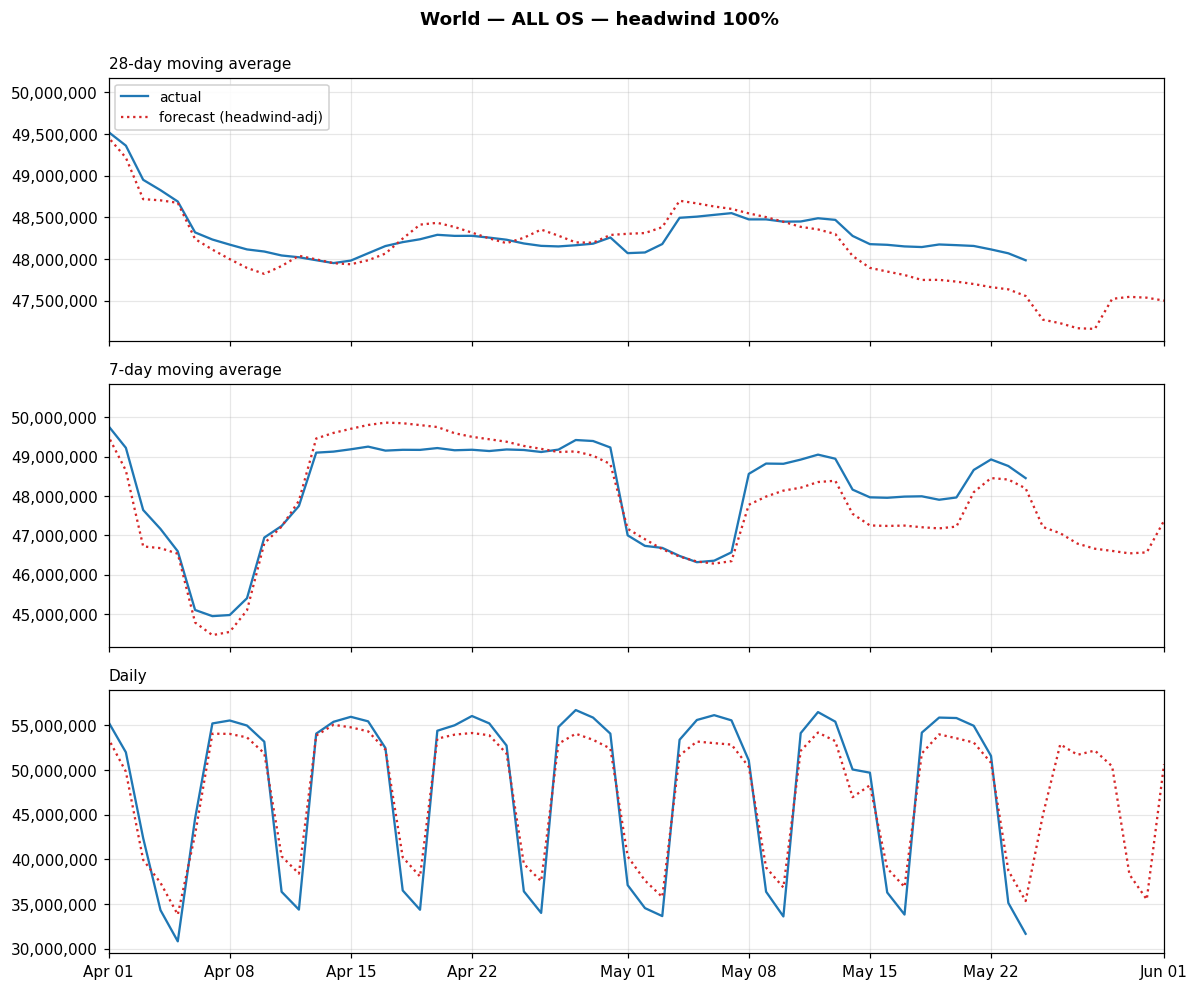

In [7]:
# [plot-world-total]
show_entity(world_all, title_suffix="headwind 100%")


## 2. North America

Forecast-resolved: US, CA, MX. Headwind is distributed pro-rata by each entity's share of world ALL-OS DAU on the share-anchor date.

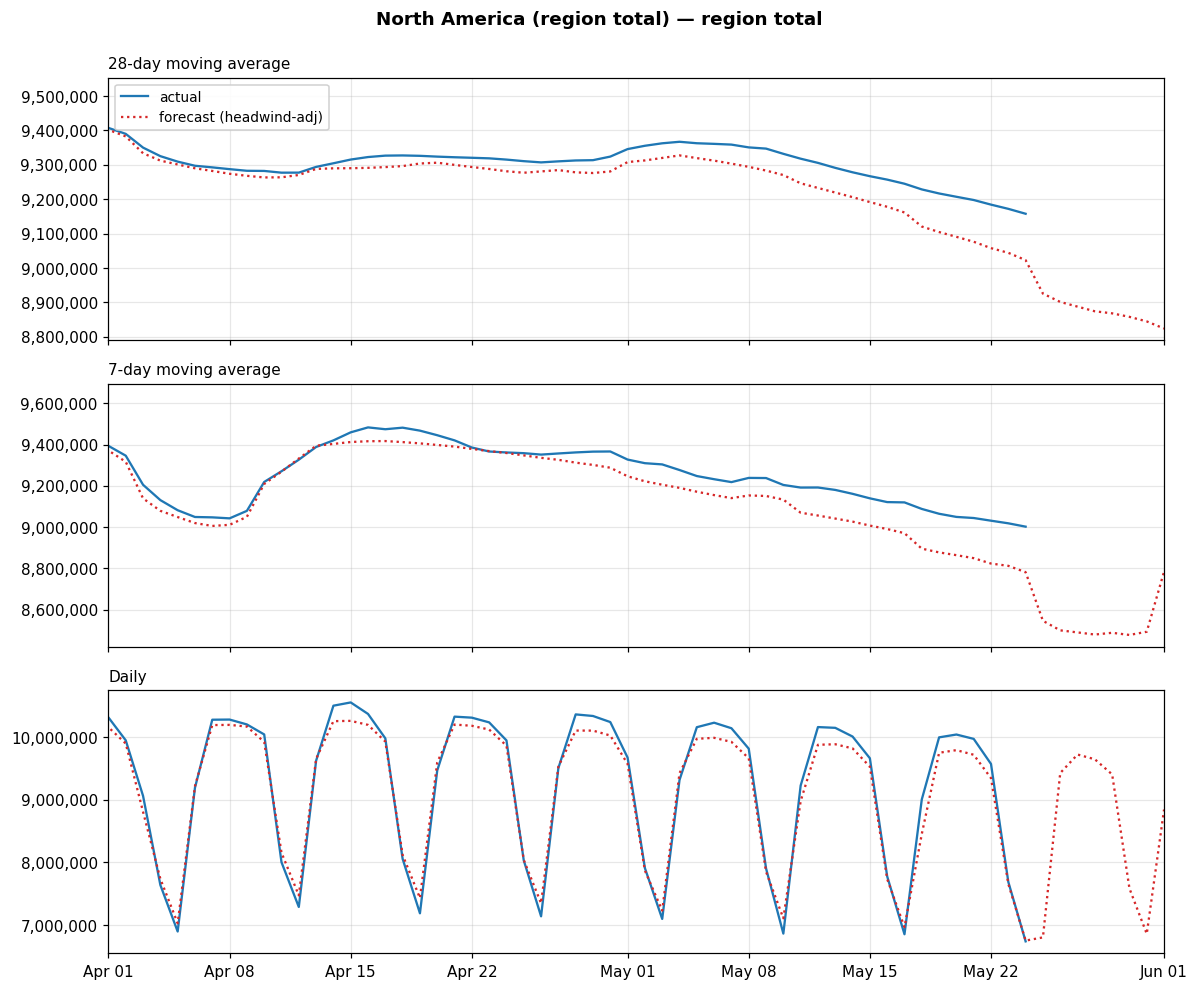

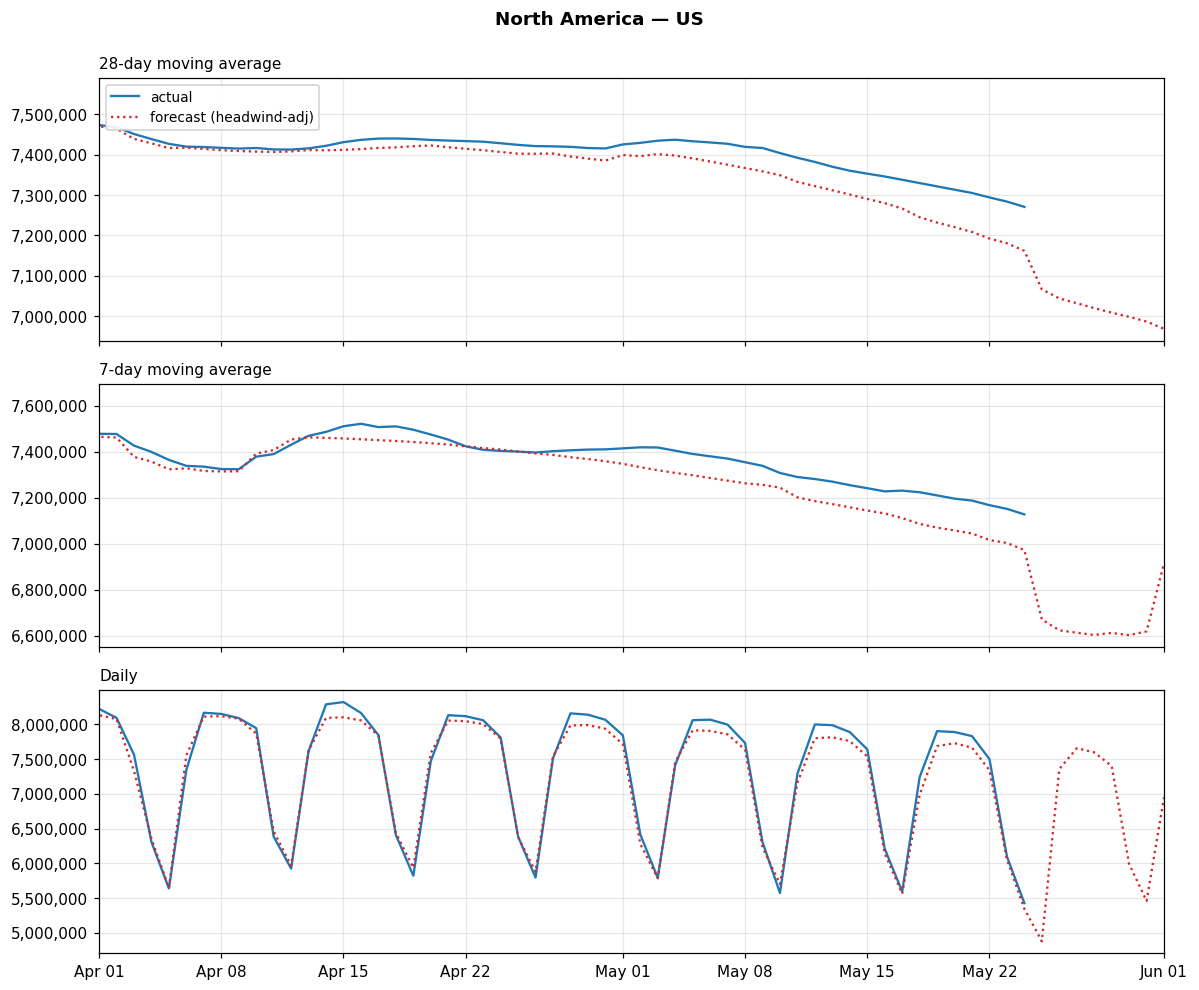

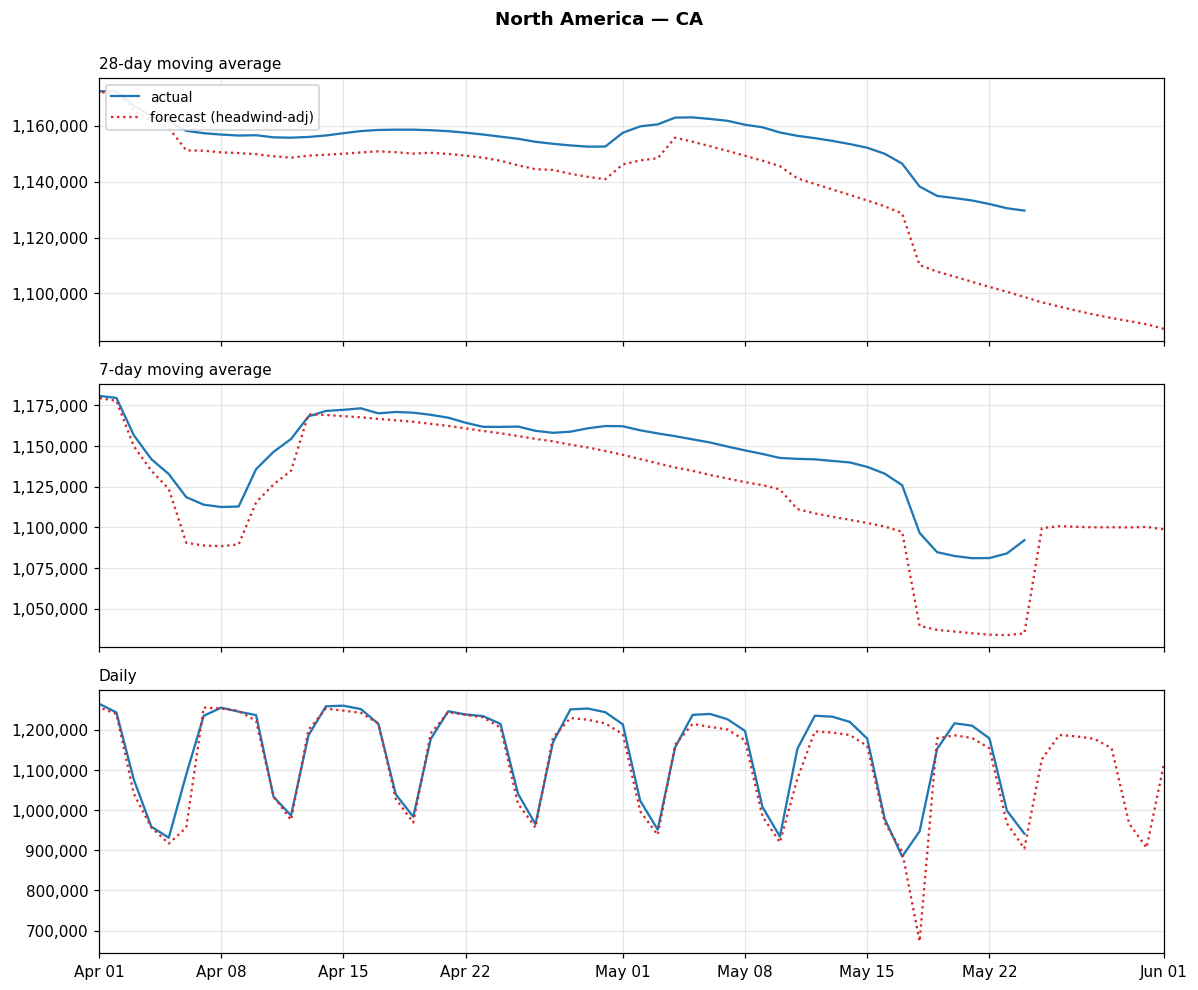

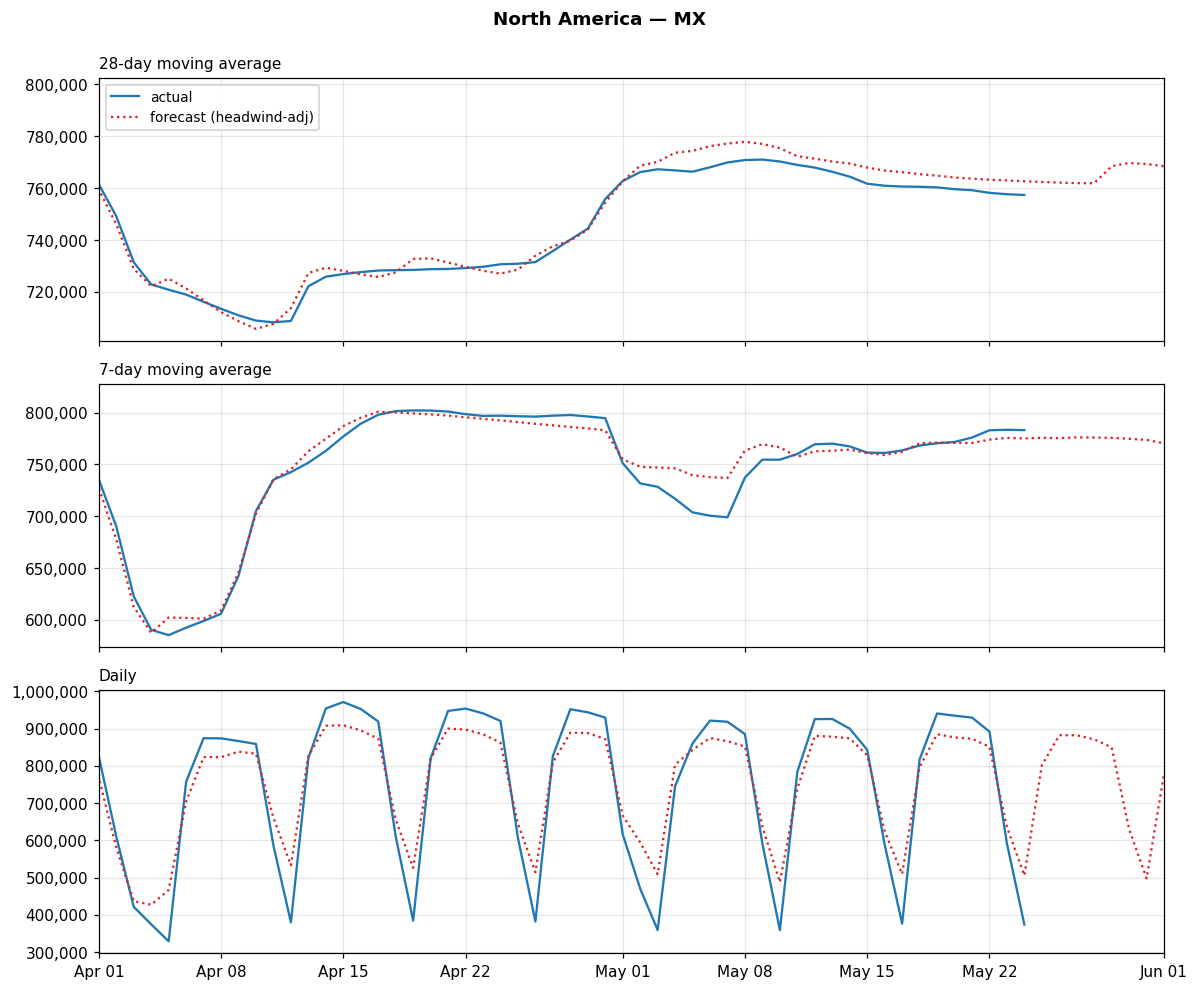

In [8]:
# [plot-north-america]
region = 'North America'
show_entity(region_entities[region], title_suffix='region total')
show_entities(region_country_entities[region])


## 3. South America

Forecast-resolved: AR, BR.

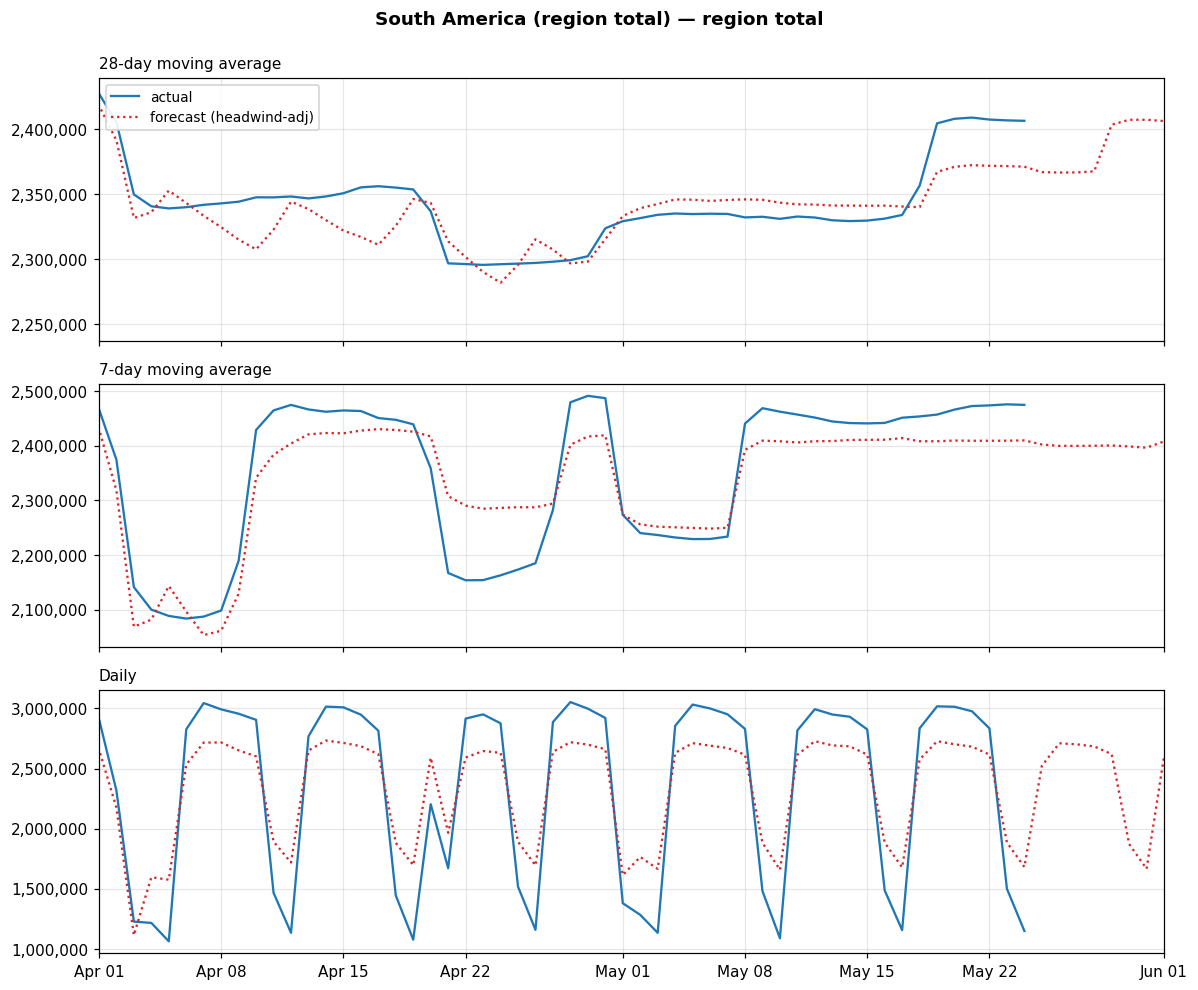

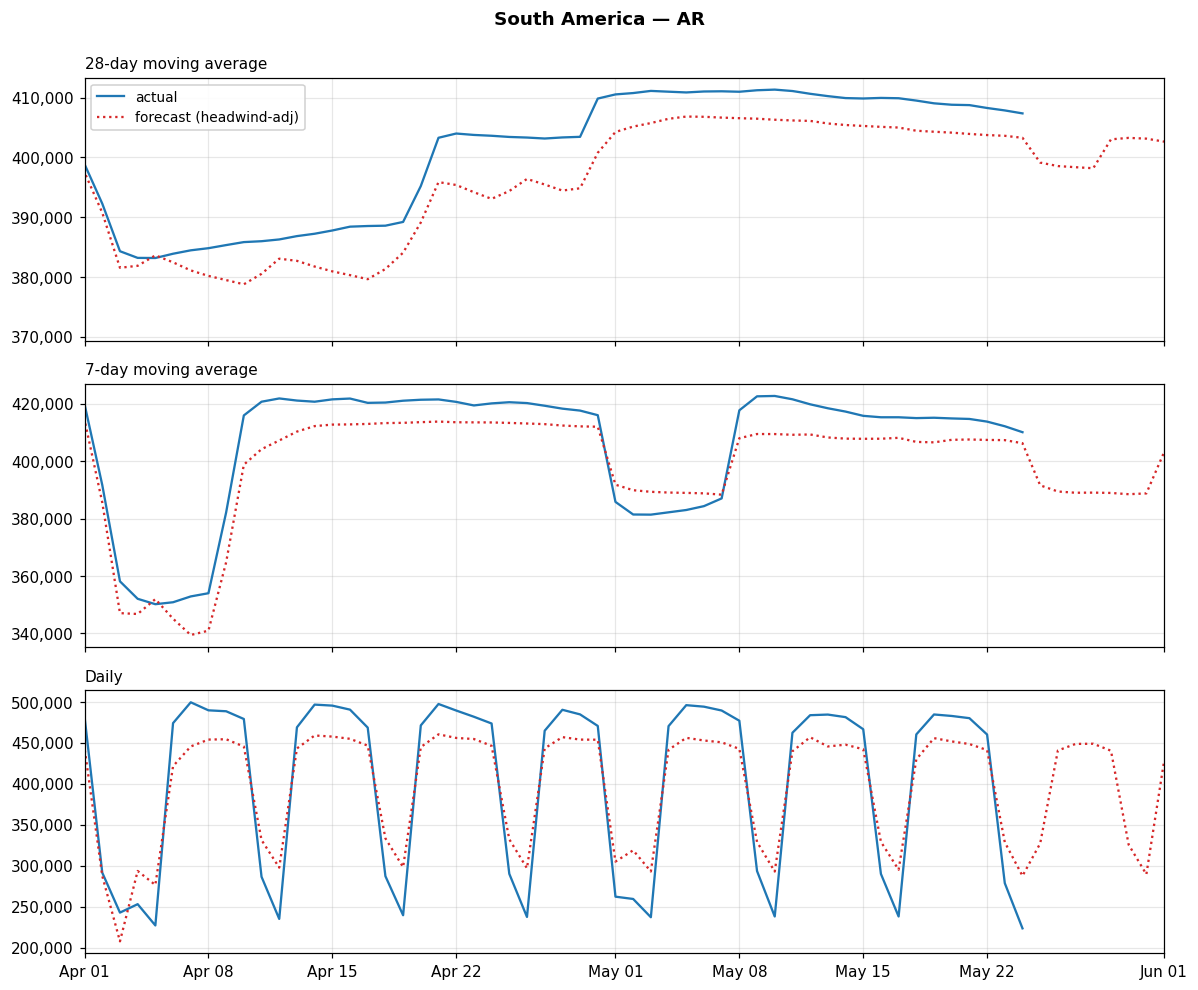

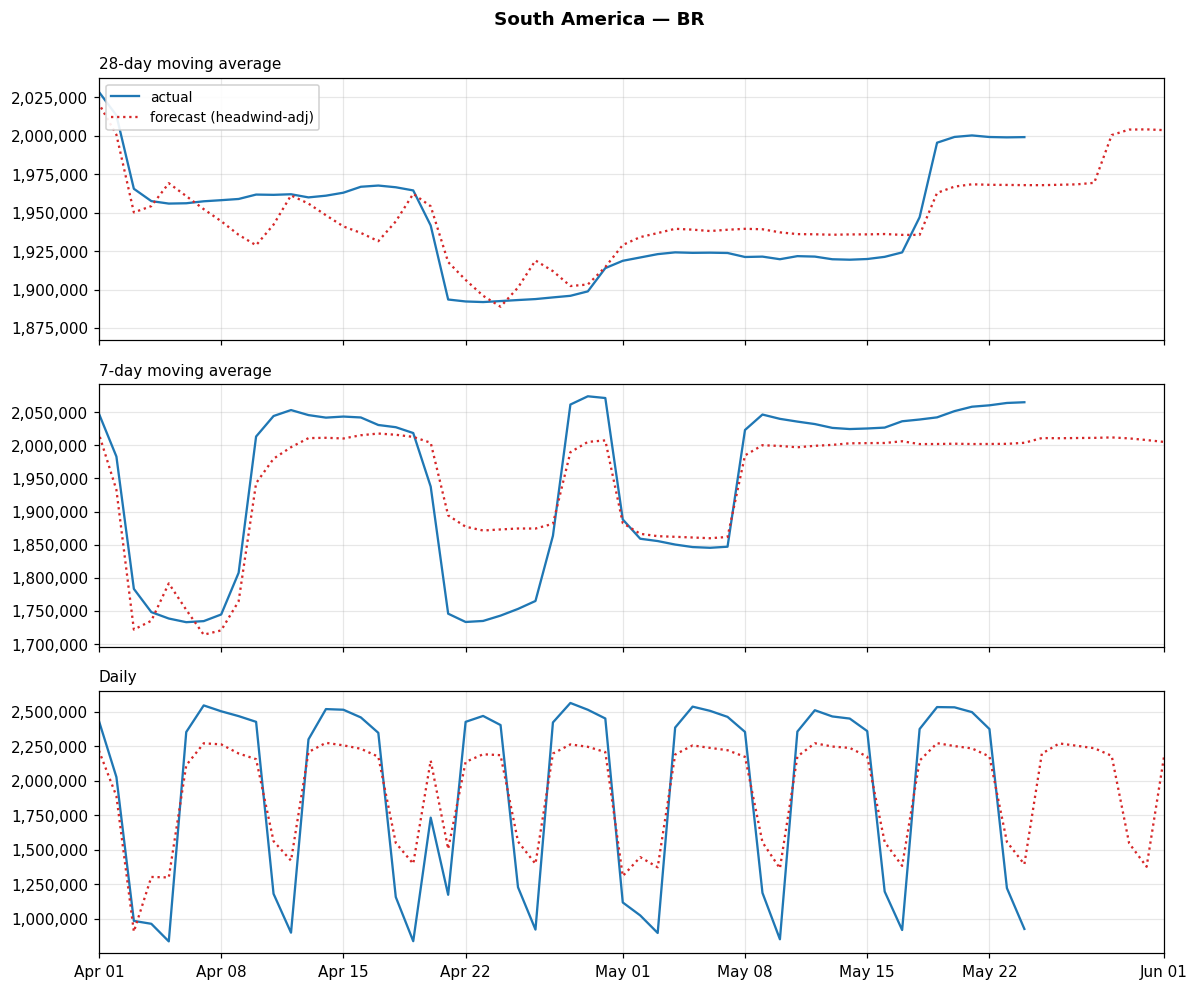

In [9]:
# [plot-south-america]
region = 'South America'
show_entity(region_entities[region], title_suffix='region total')
show_entities(region_country_entities[region])


## 4. Western Europe

Forecast-resolved individually: DE, FR, IT. The model's ROW bucket carries the rest of Western Europe (GB, ES, NL, etc.), so the **WE-all-countries actuals-only** chart at the end of this section shows the full regional picture; we just don't have a forecast comparison for it.

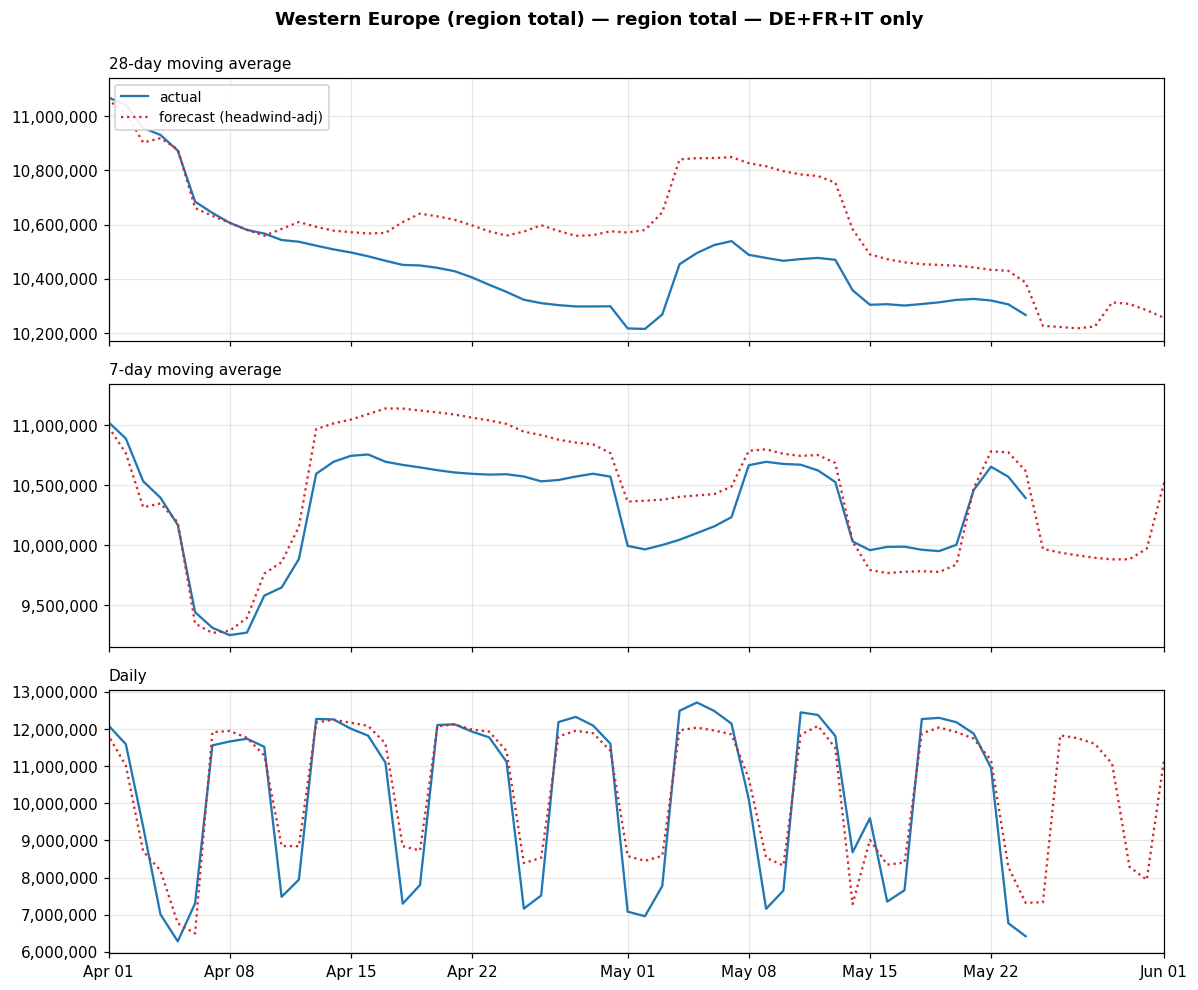

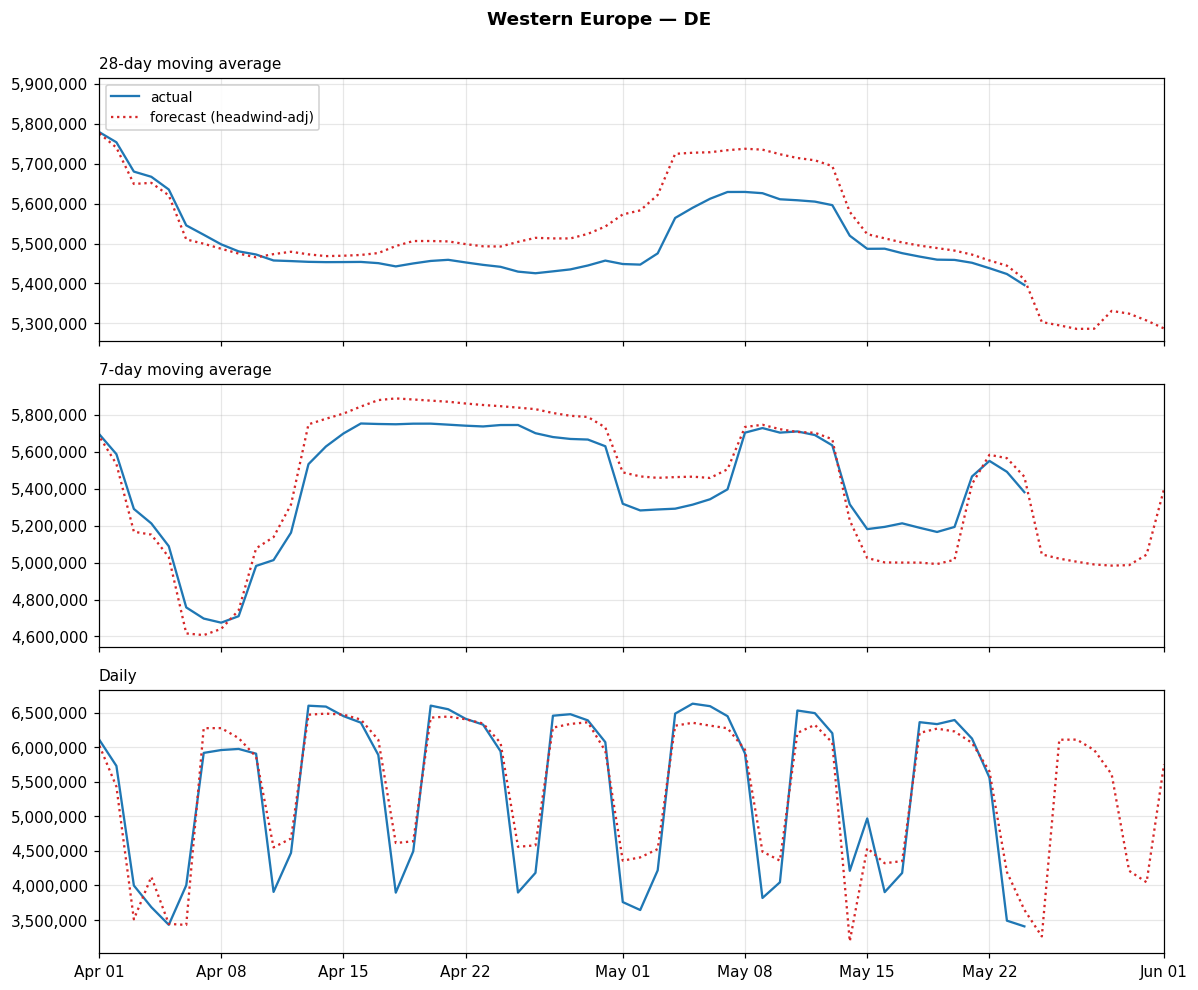

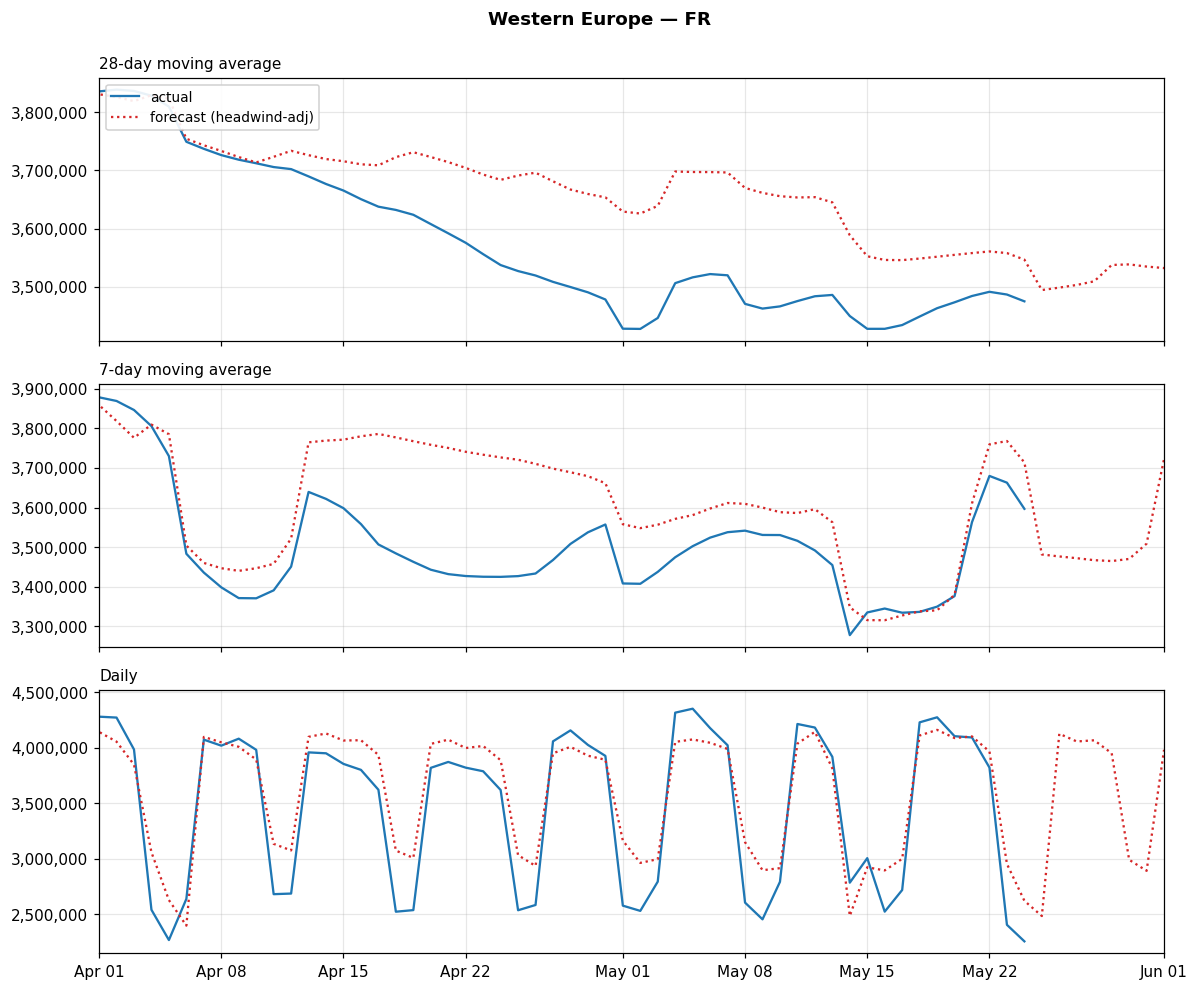

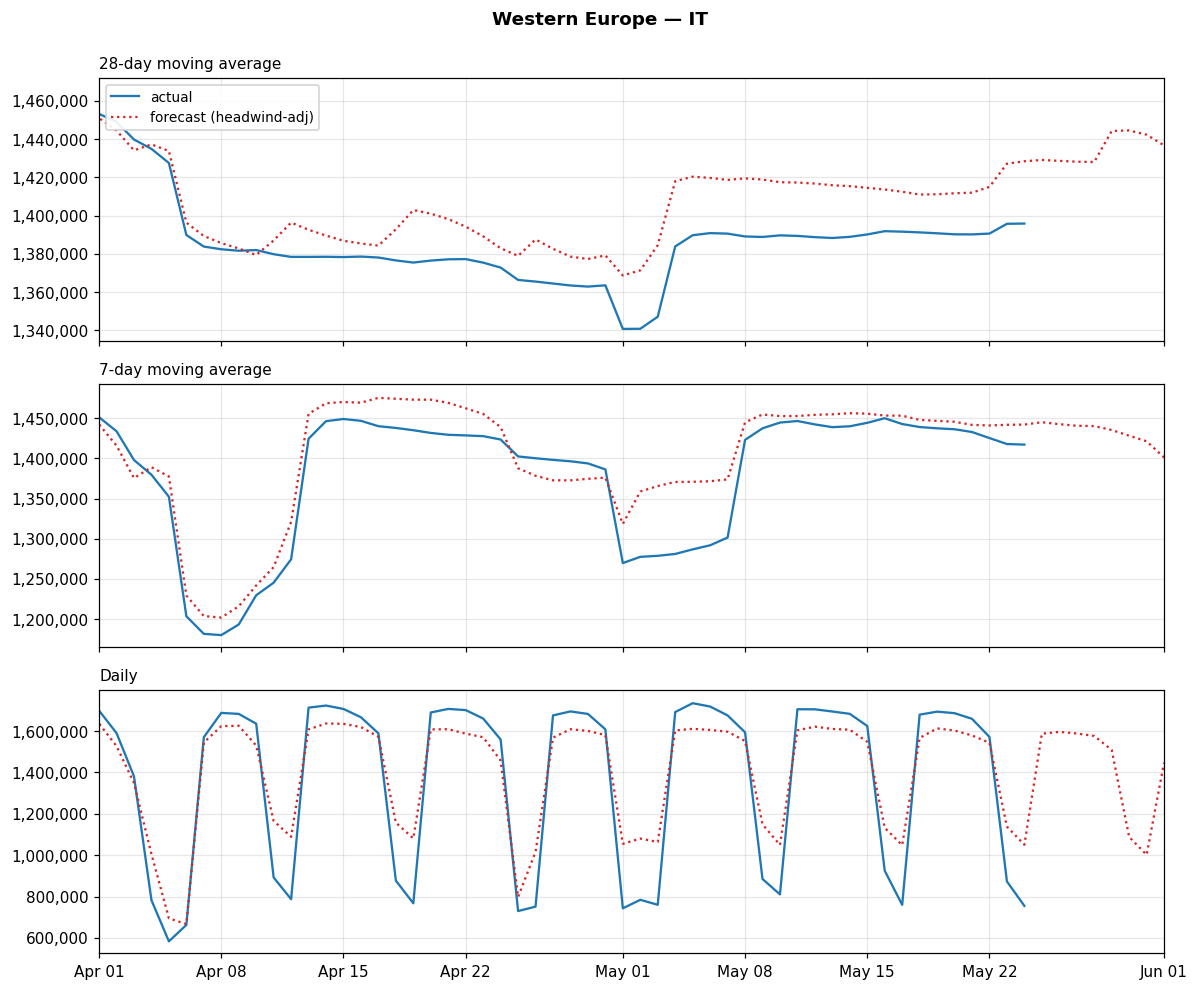

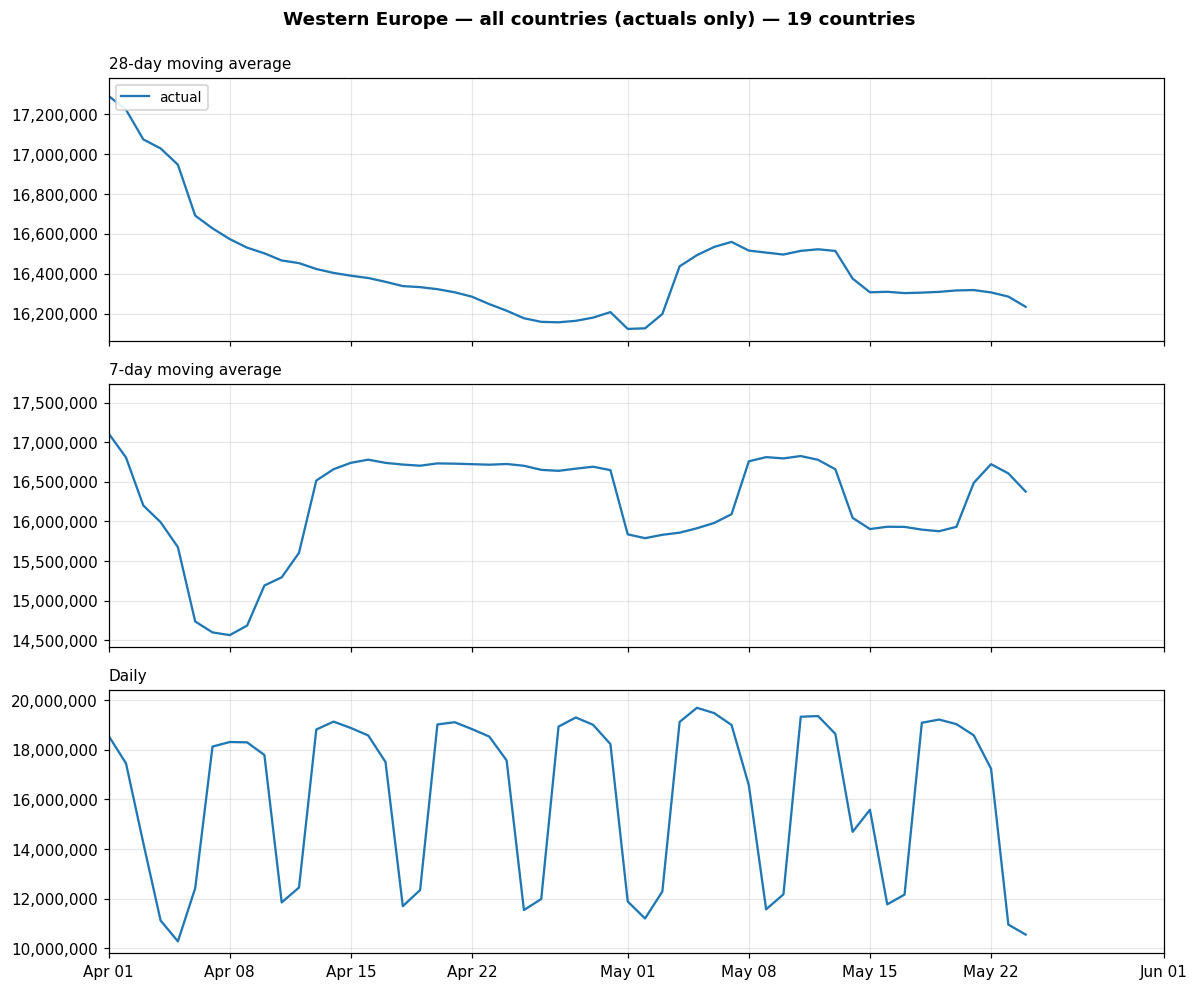

In [10]:
# [plot-western-europe]
region = 'Western Europe'
show_entity(region_entities[region], title_suffix='region total — DE+FR+IT only')
show_entities(region_country_entities[region])
show_entity(we_full_entity, title_suffix=f'{len(WESTERN_EUROPE_FULL)} countries')


## 5. Eastern Europe (incl. RU)

Forecast-resolved: PL, RU. (Other Eastern European countries fold into the ROW bucket.)

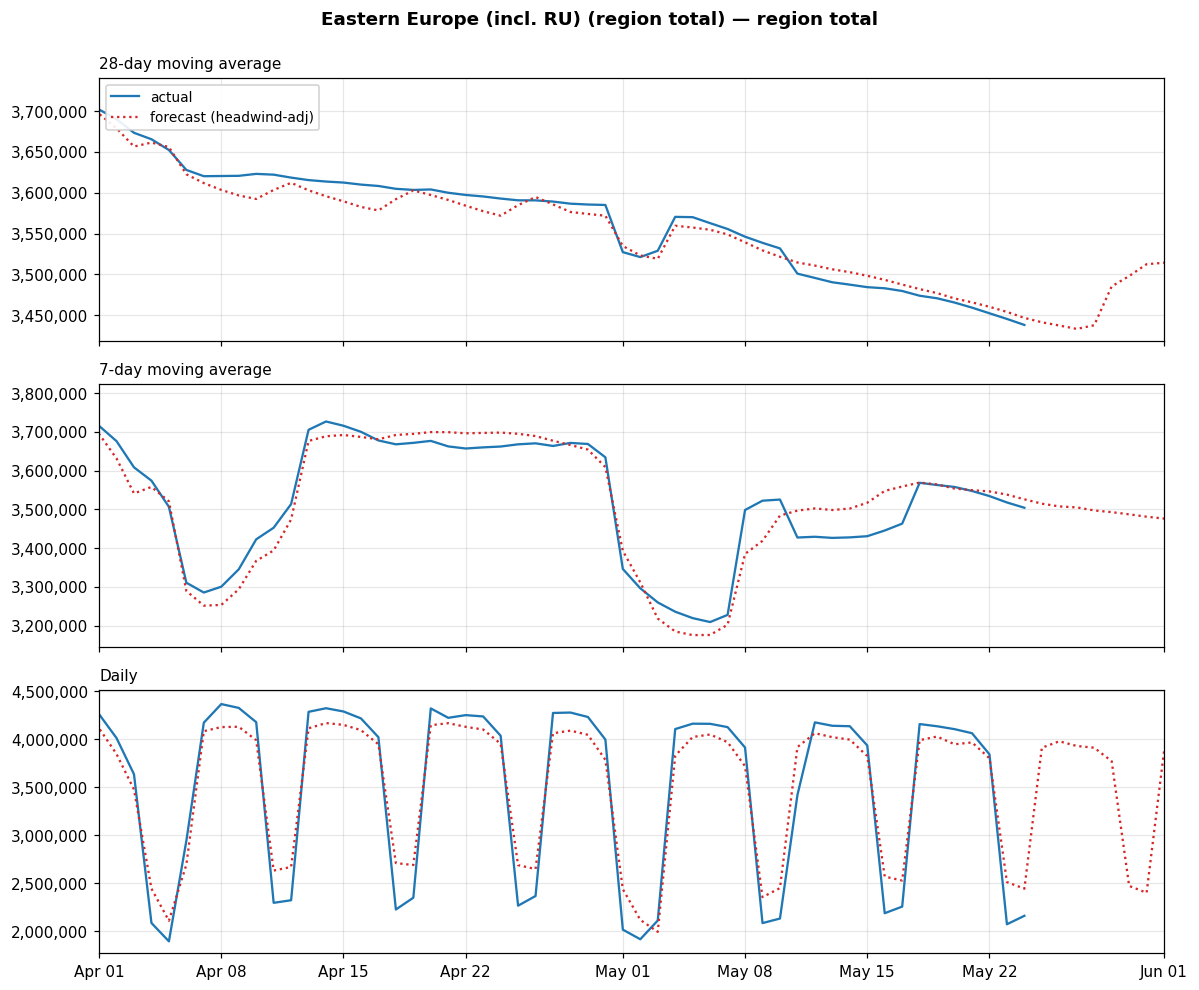

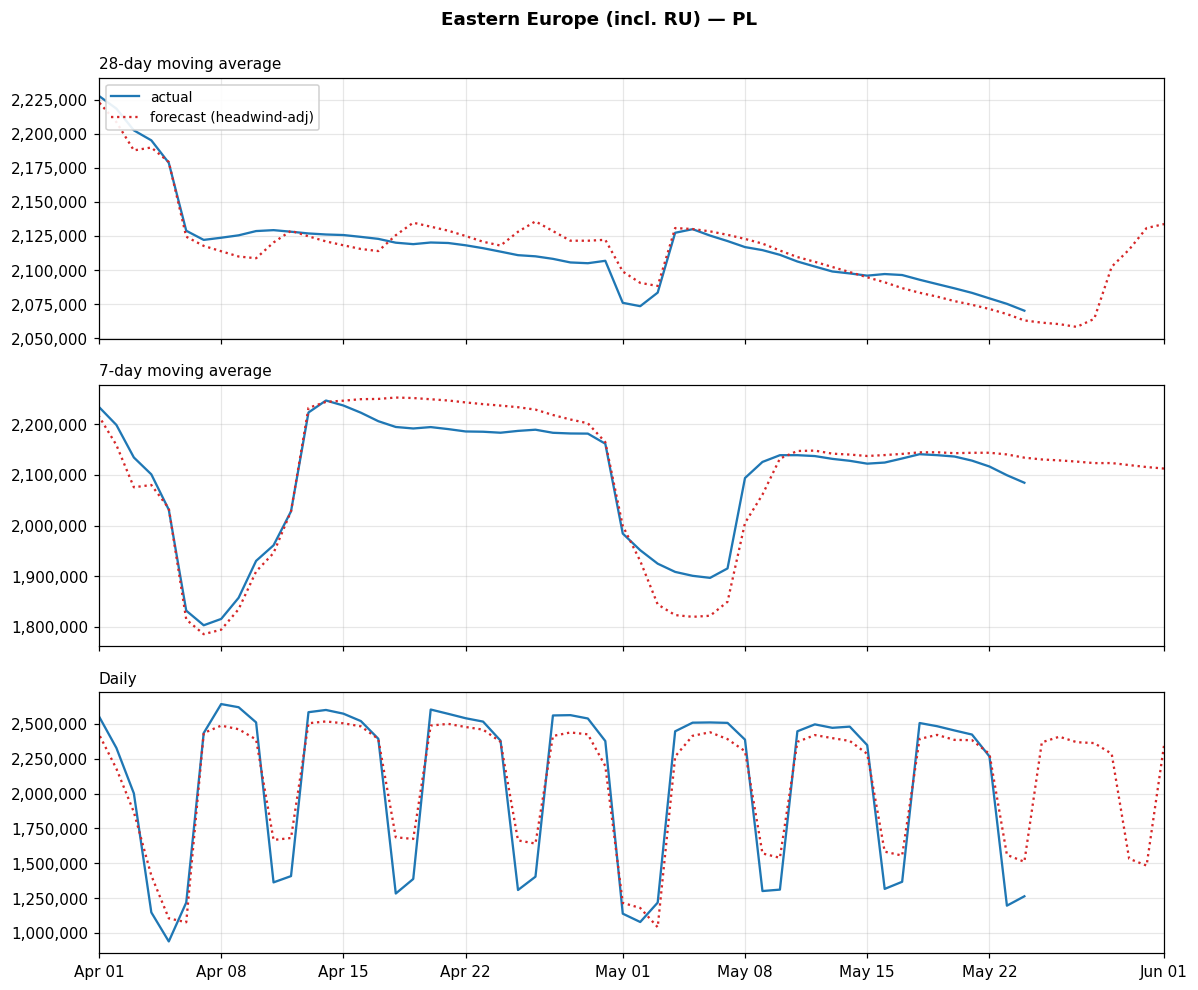

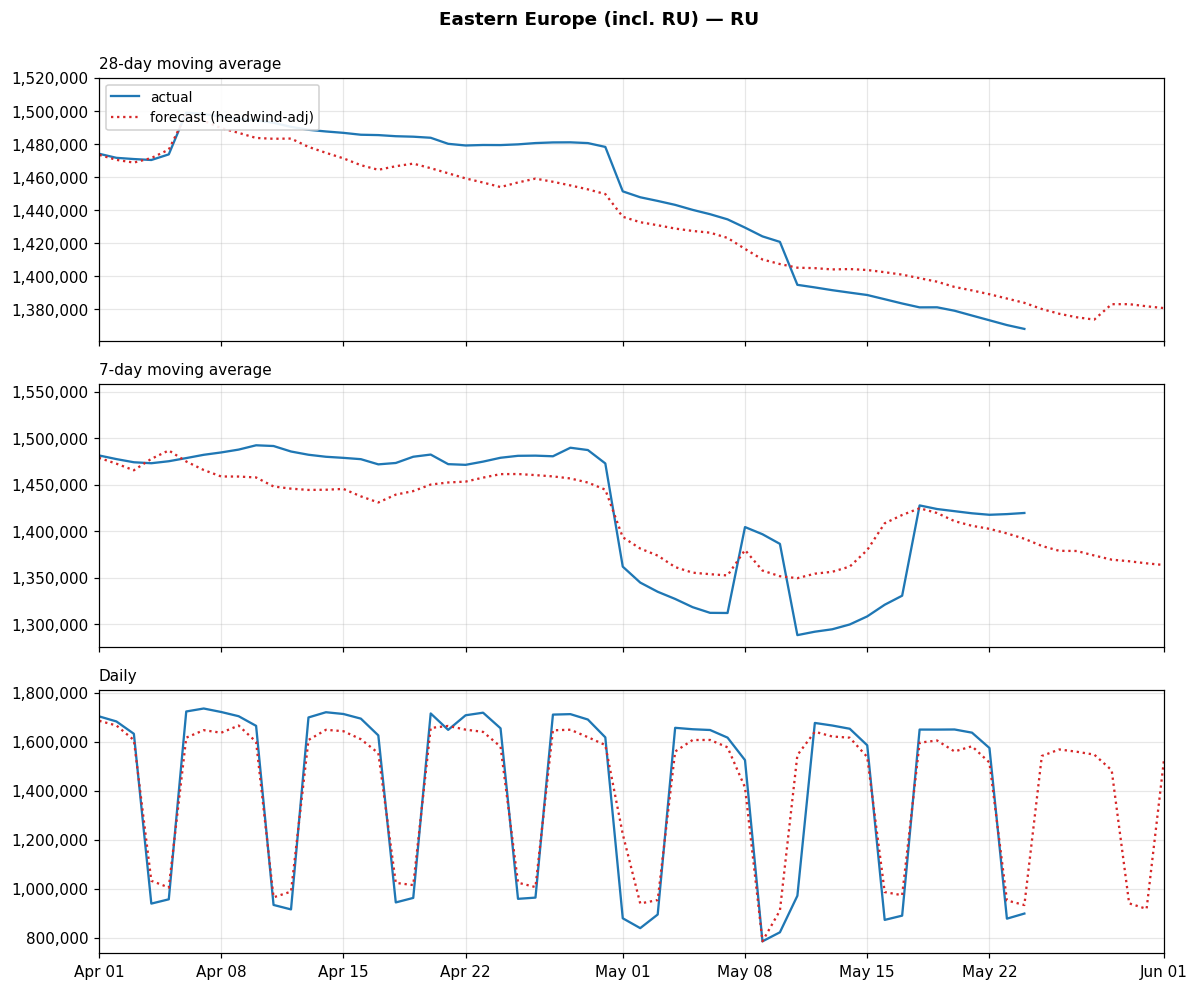

In [11]:
# [plot-eastern-europe]
region = 'Eastern Europe (incl. RU)'
show_entity(region_entities[region], title_suffix='region total')
show_entities(region_country_entities[region])


## 6. Asia (excl. RU)

Forecast-resolved: CN, ID, IN, JP. CN is a known low-forecast/high-actual outlier (forecast bucket is ~277k DAU, actuals are ~1.1M DAU).

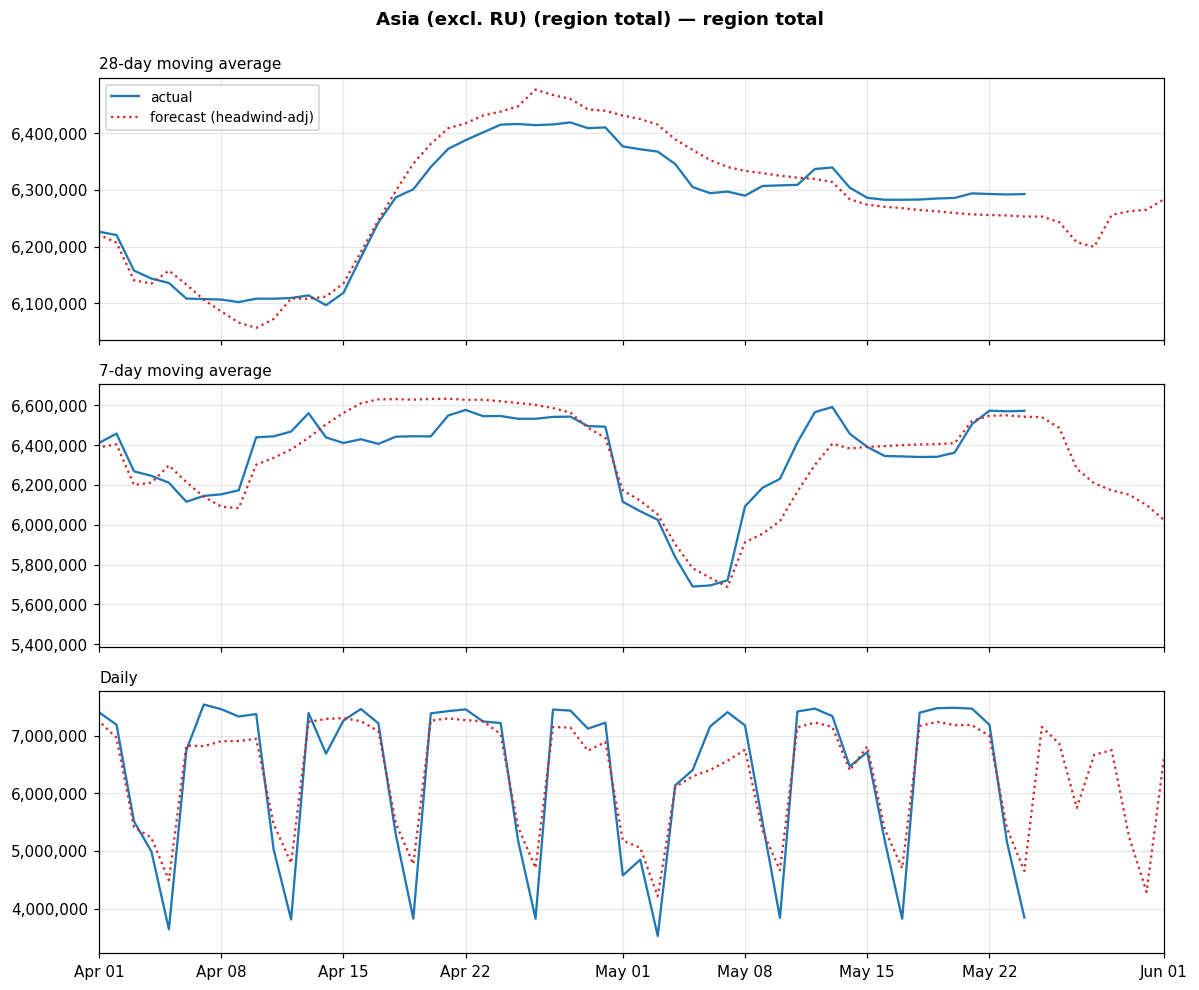

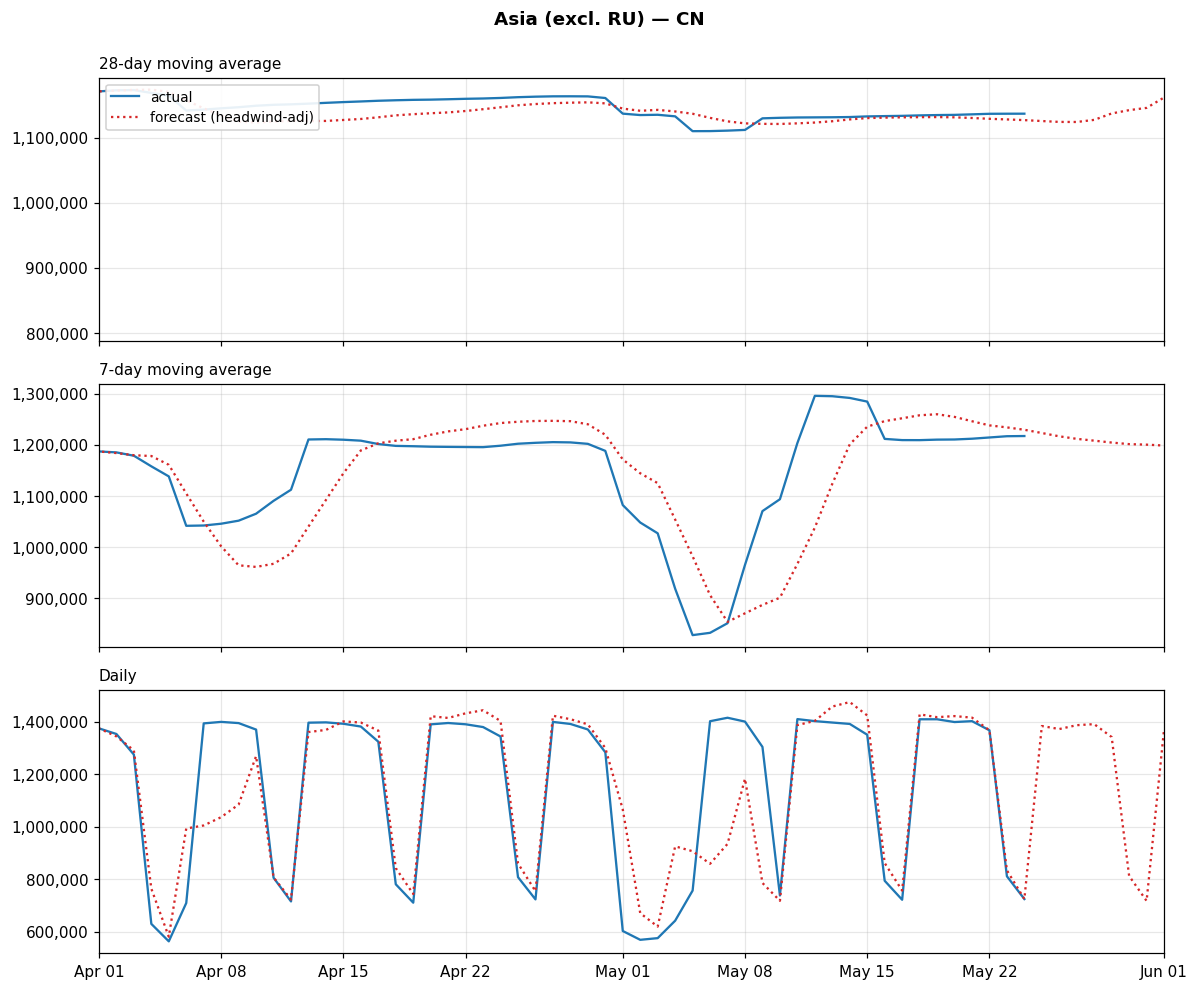

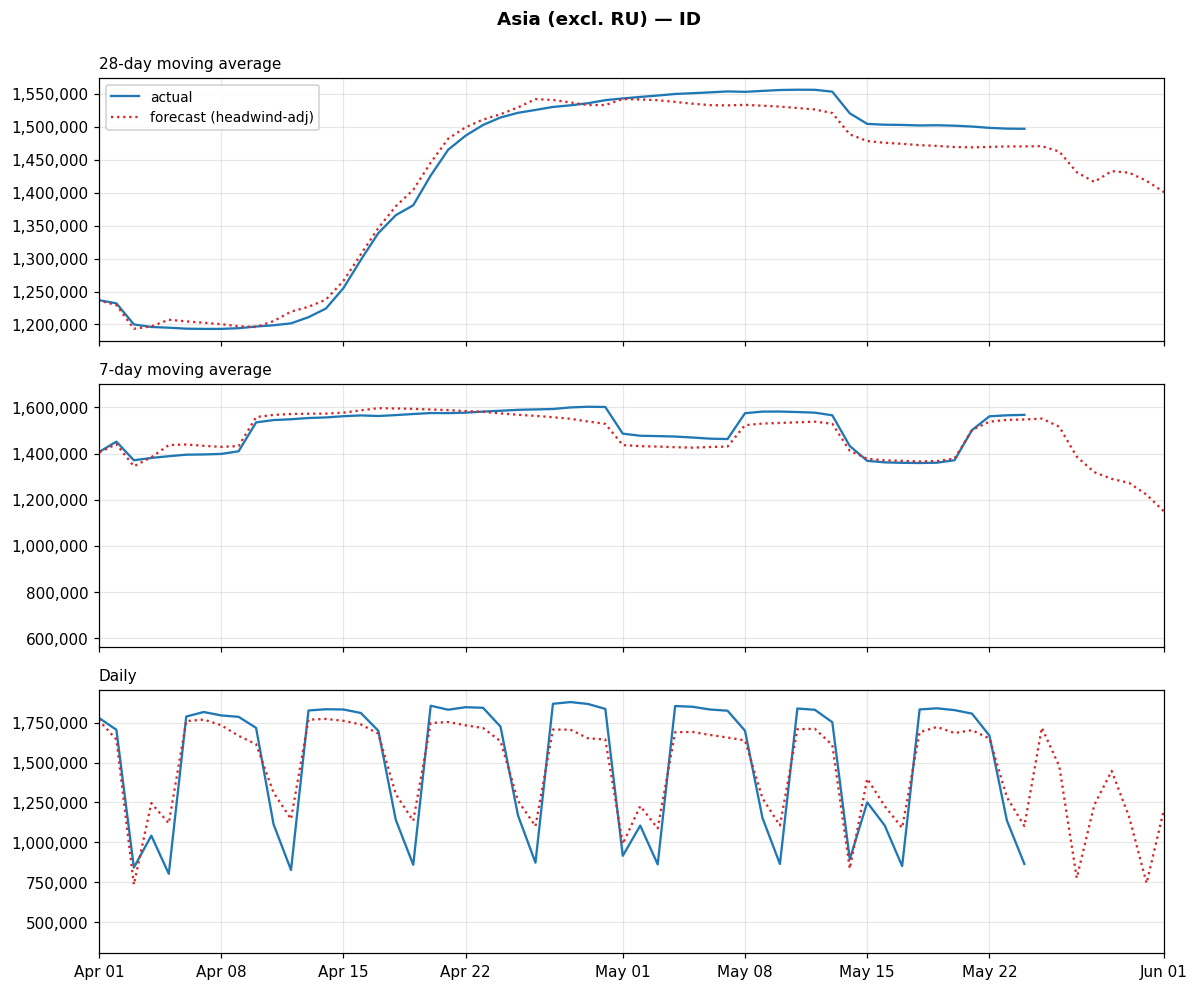

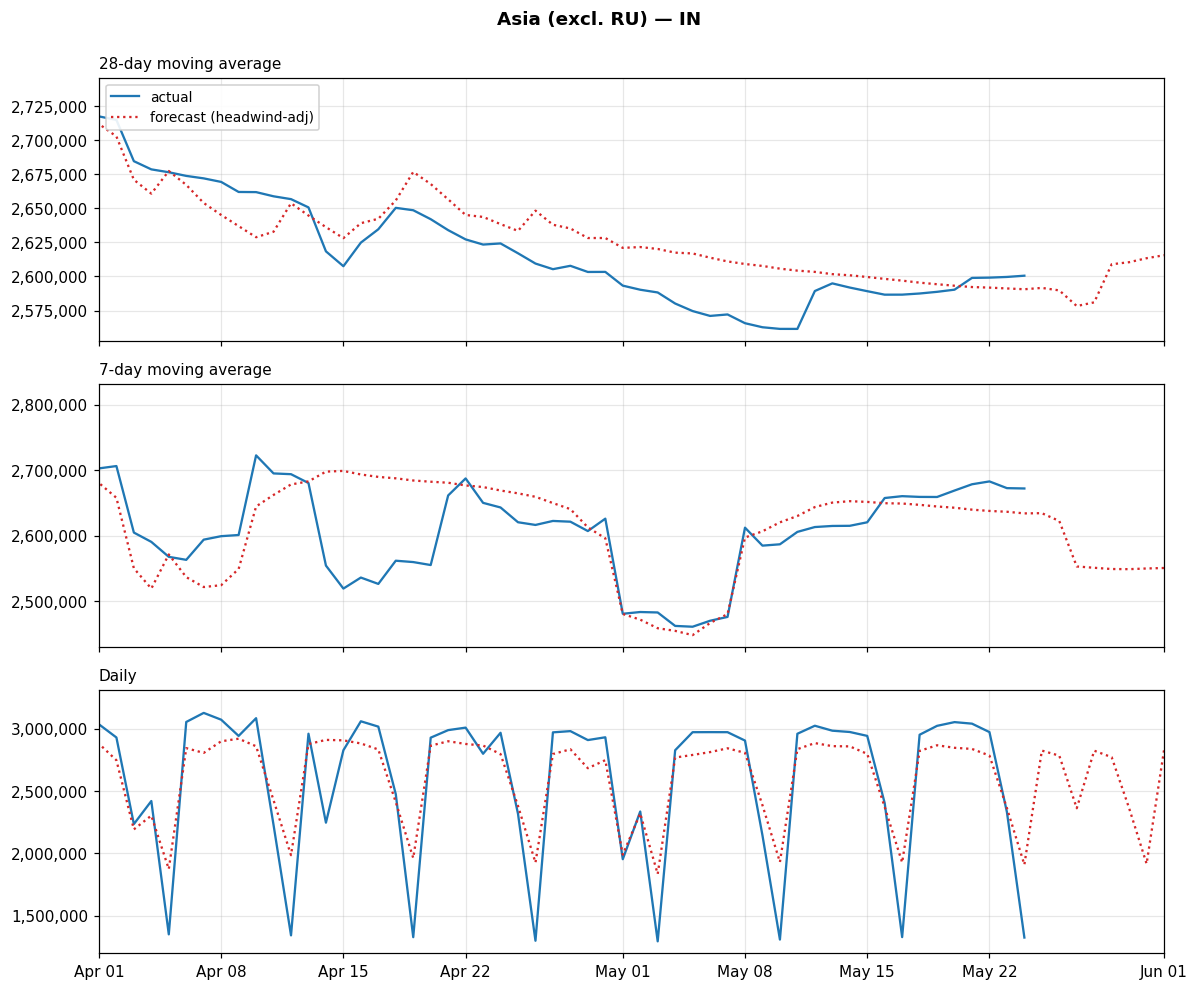

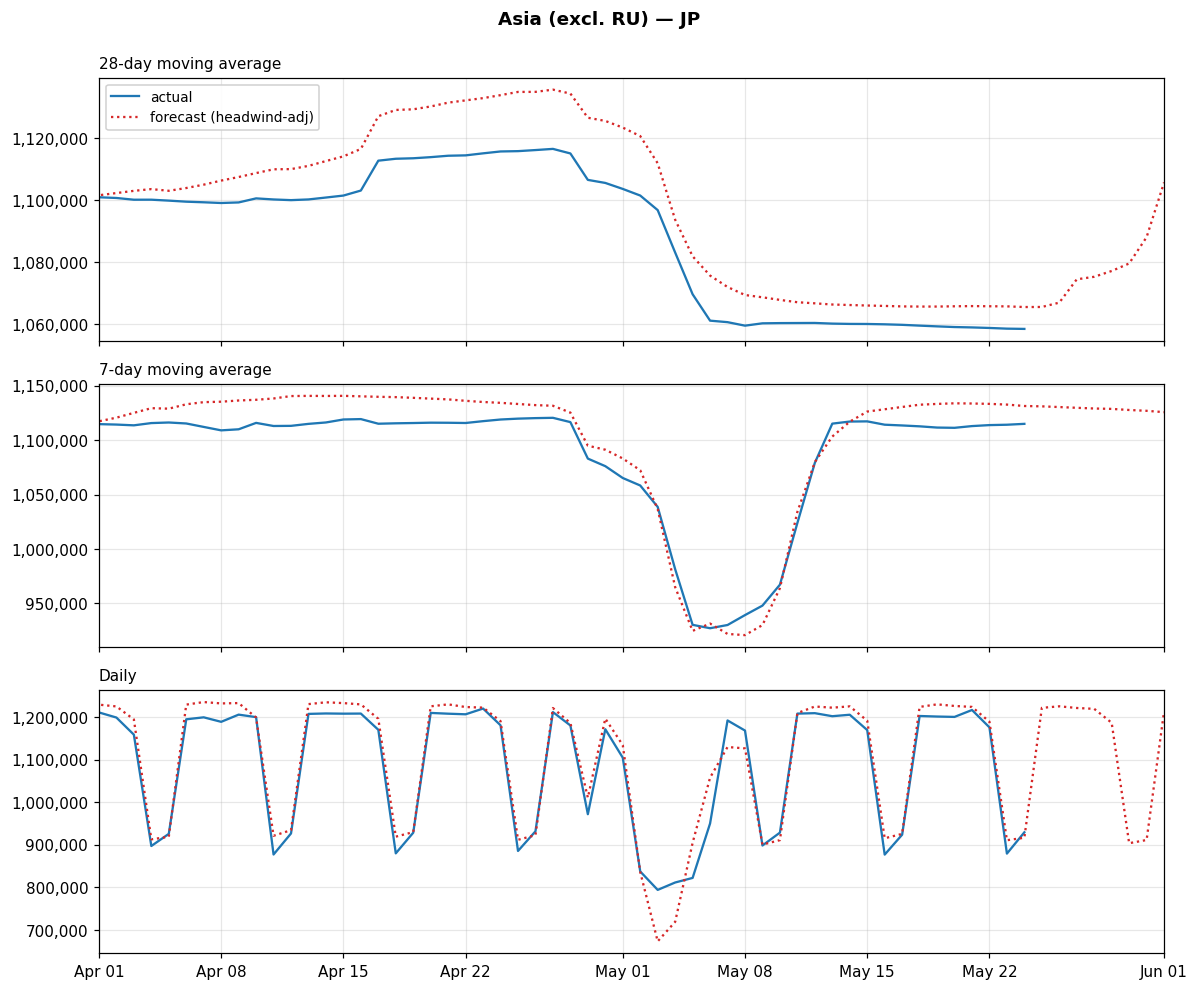

In [12]:
# [plot-asia]
region = 'Asia (excl. RU)'
show_entity(region_entities[region], title_suffix='region total')
show_entities(region_country_entities[region])


## 7. Rest of World

The ROW bucket holds every actuals country not resolved individually by the forecast (everything outside AR/BR/CA/CN/DE/FR/ID/IN/IT/JP/MX/PL/RU/US, and excluding IR).

**Selection rule.** A country gets its own chart if it (a) represents ≥5% of post-FORECAST_START ROW DAU, or (b) contributes ≥5% to the absolute |actual − forecast| gap. The forecast line on each per-country panel is **implied**: it's the headwind-adjusted ROW forecast multiplied by the country's share of ROW actuals in the post-FORECAST window, so all per-country implied forecasts plus the residual reproduce the ROW total.

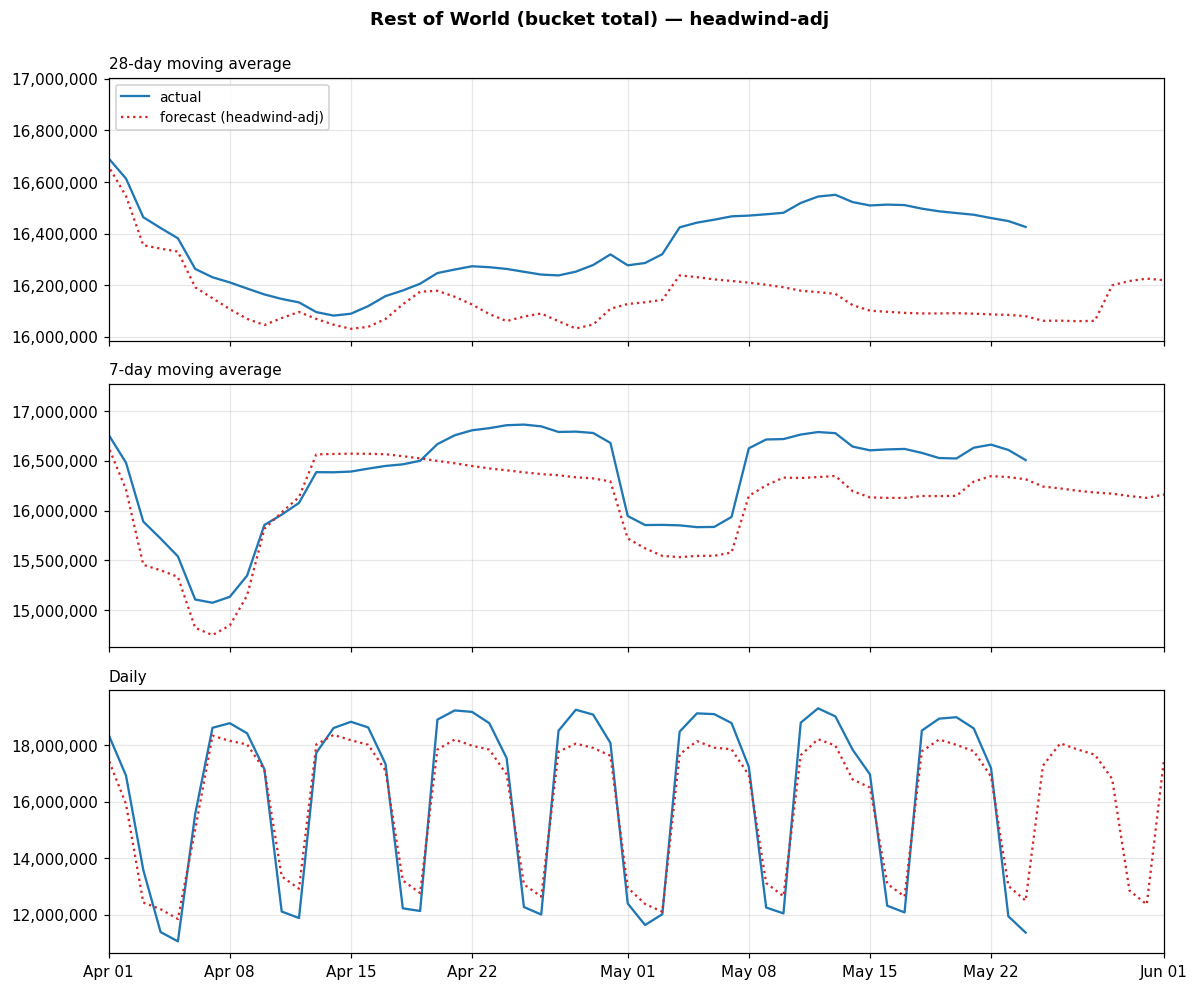

In [13]:
# [plot-row-total]
show_entity(row_total_entity, title_suffix='headwind-adj')


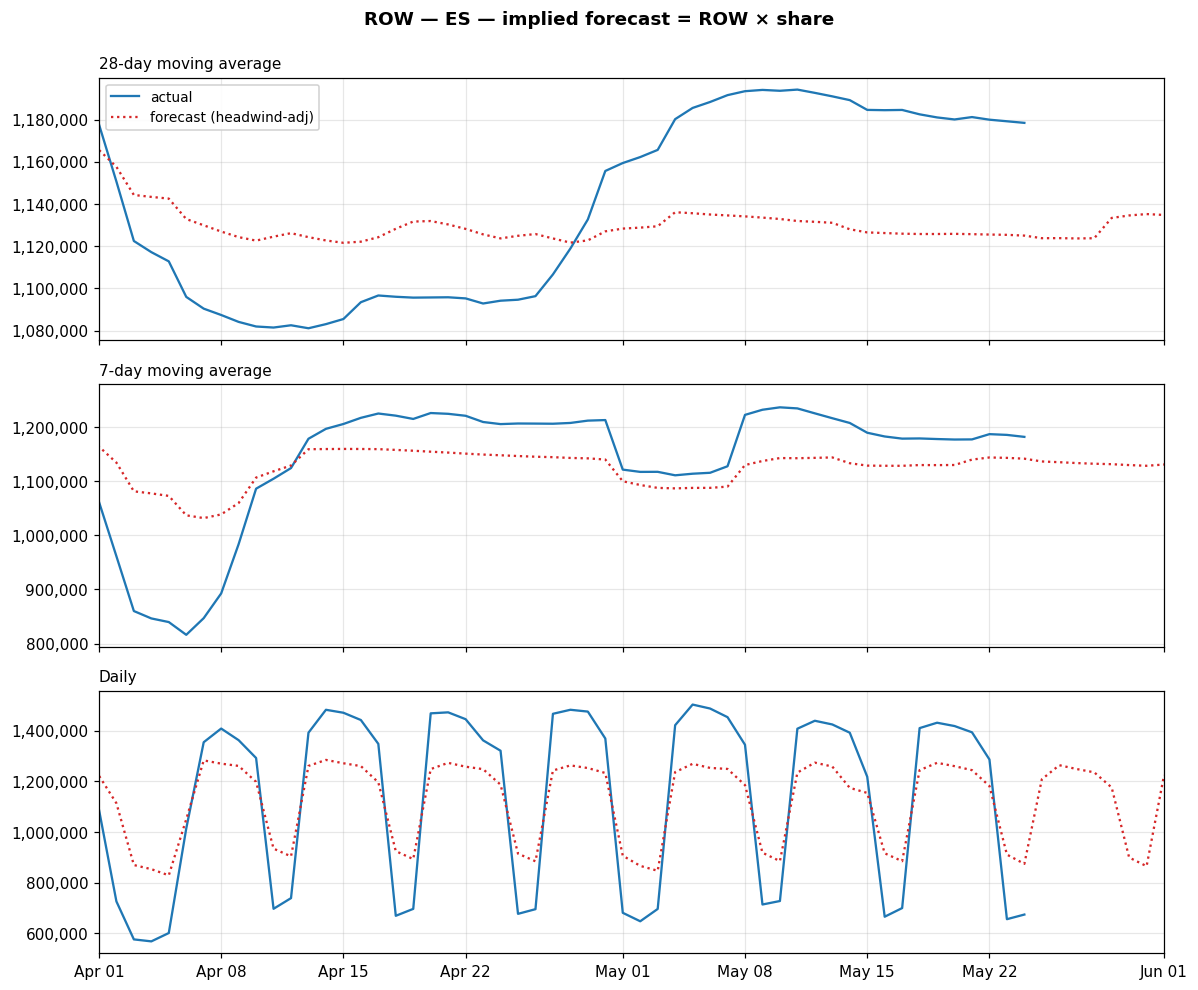

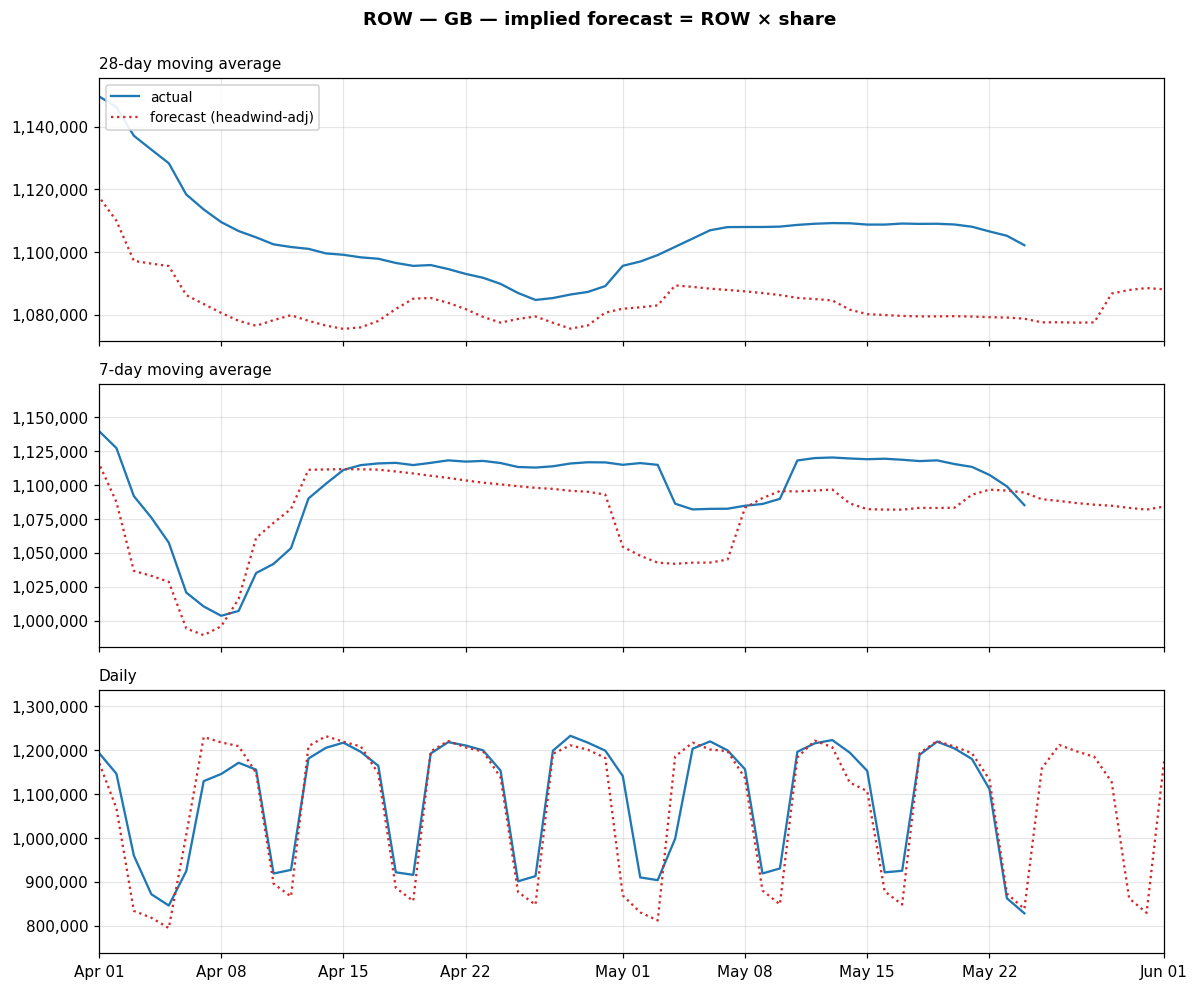

In [14]:
# [plot-row-countries]
show_entities(row_country_entities, title_suffix='implied forecast = ROW × share')


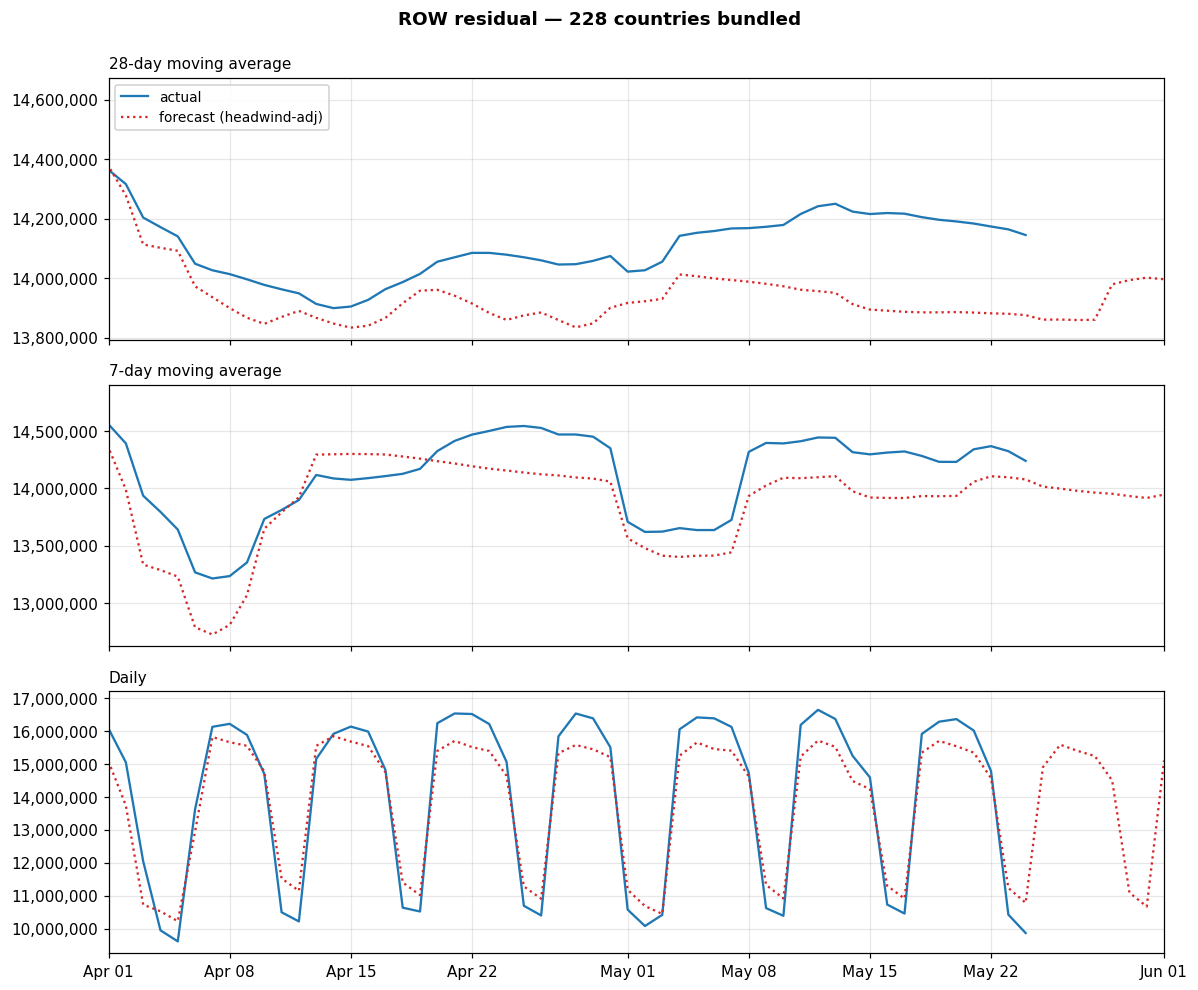

In [15]:
# [plot-row-residual]
show_entity(row_residual_entity)


## 8. OS classes (world-level)

Each OS class is treated like a country: the forecast resolves at the coarse level (`modern_windows`, `winX`, `other`) and we split actuals further into Windows 10, Windows 11, mac (Darwin), Linux, and the unclassified residual. For fine classes whose parent forecast bucket is shared (e.g. win10/win11 both inside `modern_windows`), the per-class forecast line is **implied**: parent-bucket forecast × (this fine class's share of the parent class's actuals during the post-FORECAST window). Per-class implied forecasts sum back to the parent forecast.

Fine → coarse mapping:
- `win10`, `win11`, `win_modern_other` → `modern_windows` (forecast bucket)
- `win_older` → `winX` (forecast bucket; direct, not implied)
- `mac`, `linux`, `other_os` → `other` (forecast bucket)

In [16]:
# [build-os-entities]
# Aggregate fine-OS actuals across countries (post Iran exclusion) and the
# coarse-OS forecast lines at the world level.
world_actuals_fine = (
    actuals_fine.groupby(['date', 'os_class_fine'], as_index=False)['dau']
    .sum()
)

def _world_fine_actual(fine_class):
    sub = world_actuals_fine[world_actuals_fine['os_class_fine'] == fine_class]
    return sub.set_index('date')['dau'].sort_index()


def _world_coarse_forecast(coarse_class):
    return _forecast_series('ALL', coarse_class)


# Share each fine class contributes within its parent coarse class, computed
# over the post-FORECAST window so the implied forecast lines up with the
# regime we're trying to explain.
post_dates = world_actuals_fine['date'] >= FORECAST_START
fine_post_mean = (
    world_actuals_fine[post_dates]
    .groupby('os_class_fine')['dau']
    .mean()
)
coarse_post_mean = pd.Series({
    coarse: fine_post_mean.loc[
        [k for k, v in OS_FINE_TO_COARSE.items() if v == coarse and k in fine_post_mean.index]
    ].sum()
    for coarse in ['modern_windows', 'winX', 'other']
})
share_within_parent = {
    fine: float(fine_post_mean[fine] / coarse_post_mean[OS_FINE_TO_COARSE[fine]])
    for fine in OS_FINE_TO_COARSE if fine in fine_post_mean.index
}

# Headwind share for each coarse forecast bucket (= bucket share of world ALL forecast).
_world_all_anchor = forecast_df.query(
    "country == 'ALL' and os_class == 'ALL' and target_date == @SHARE_ANCHOR_DATE"
)['dau'].iloc[0]
coarse_headwind_share = {}
for coarse in ['modern_windows', 'winX', 'other']:
    coarse_headwind_share[coarse] = float(
        forecast_df.query(
            "country == 'ALL' and os_class == @coarse and target_date == @SHARE_ANCHOR_DATE"
        )['dau'].iloc[0] / _world_all_anchor
    )

print('Fine-OS post-window mean DAU and share of parent coarse class:')
for fine, coarse in OS_FINE_TO_COARSE.items():
    if fine in fine_post_mean.index:
        share = share_within_parent[fine]
        mean = fine_post_mean[fine]
        print(f'  {fine:<18} (parent={coarse:<14}) mean={mean:>14,.0f}  share-of-parent={share:>6.1%}')
print('\nCoarse-class headwind shares (fraction of world headwind applied):')
for coarse, sh in coarse_headwind_share.items():
    print(f'  {coarse:<14}: {sh:>6.1%}')

# Skip near-zero fine classes (currently win_modern_other and other_os: ~0 DAU).
# Threshold = at least 0.5% of its parent coarse class — keeps real OSes, drops noise.
MIN_SHARE_FOR_BREAKOUT = 0.005

FINE_LABELS = {
    'win10':            'Windows 10',
    'win11':            'Windows 11',
    'win_modern_other': 'Windows 1x (other)',
    'win_older':        'Windows < 10',
    'mac':              'macOS (Darwin)',
    'linux':            'Linux',
    'other_os':         'Other / unknown OS',
}
_order = ['win10', 'win11', 'win_modern_other', 'win_older', 'mac', 'linux', 'other_os']

os_entities = []
for fine in _order:
    if fine not in fine_post_mean.index:
        continue
    share = share_within_parent[fine]
    if share < MIN_SHARE_FOR_BREAKOUT:
        print(f'  skipping {fine!r}: share-of-parent {share:.2%} below {MIN_SHARE_FOR_BREAKOUT:.1%} threshold')
        continue
    coarse = OS_FINE_TO_COARSE[fine]
    actual = _world_fine_actual(fine)
    parent_forecast = _world_coarse_forecast(coarse)
    # Implied forecast = parent-bucket forecast × fine class's share of parent actuals.
    implied = parent_forecast * share
    os_entities.append(make_entity(
        f'{FINE_LABELS[fine]} (parent: {coarse})',
        actual=actual,
        forecast=implied,
        headwind_share=coarse_headwind_share[coarse] * share,
    ))

print('\nBuilt OS entities:')
for e in os_entities:
    print(f'  {e["name"]}')


Fine-OS post-window mean DAU and share of parent coarse class:
  win10              (parent=modern_windows) mean=    14,372,215  share-of-parent= 37.7%
  win11              (parent=modern_windows) mean=    23,791,765  share-of-parent= 62.3%
  win_modern_other   (parent=modern_windows) mean=             0  share-of-parent=  0.0%
  win_older          (parent=winX          ) mean=     2,752,296  share-of-parent=100.0%
  mac                (parent=other         ) mean=     4,092,456  share-of-parent= 59.5%
  linux              (parent=other         ) mean=     2,783,533  share-of-parent= 40.5%
  other_os           (parent=other         ) mean=           478  share-of-parent=  0.0%

Coarse-class headwind shares (fraction of world headwind applied):
  modern_windows:  80.5%
  winX          :   5.0%
  other         :  14.5%
  skipping 'win_modern_other': share-of-parent 0.00% below 0.5% threshold
  skipping 'other_os': share-of-parent 0.01% below 0.5% threshold

Built OS entities:
  Windows 1

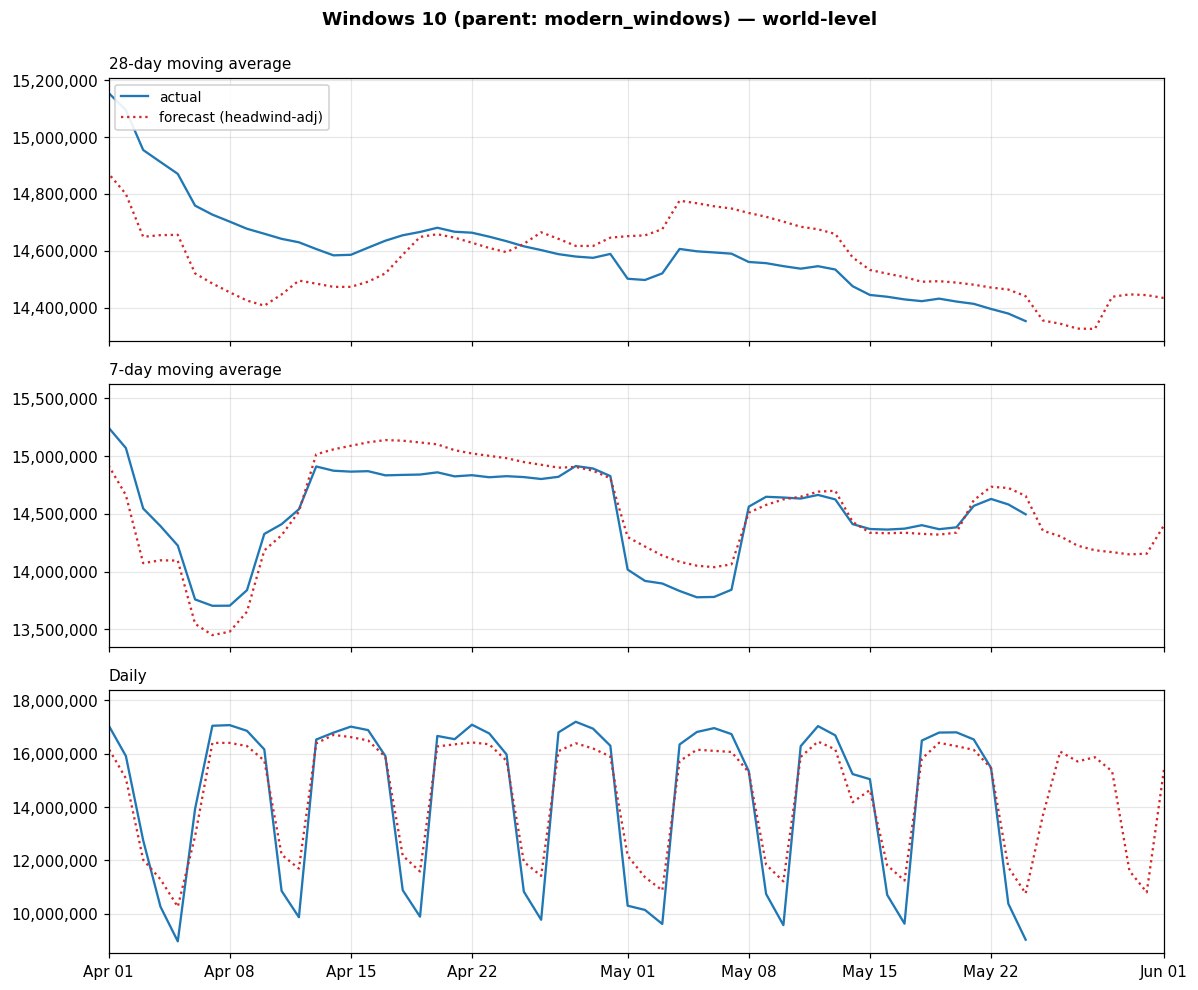

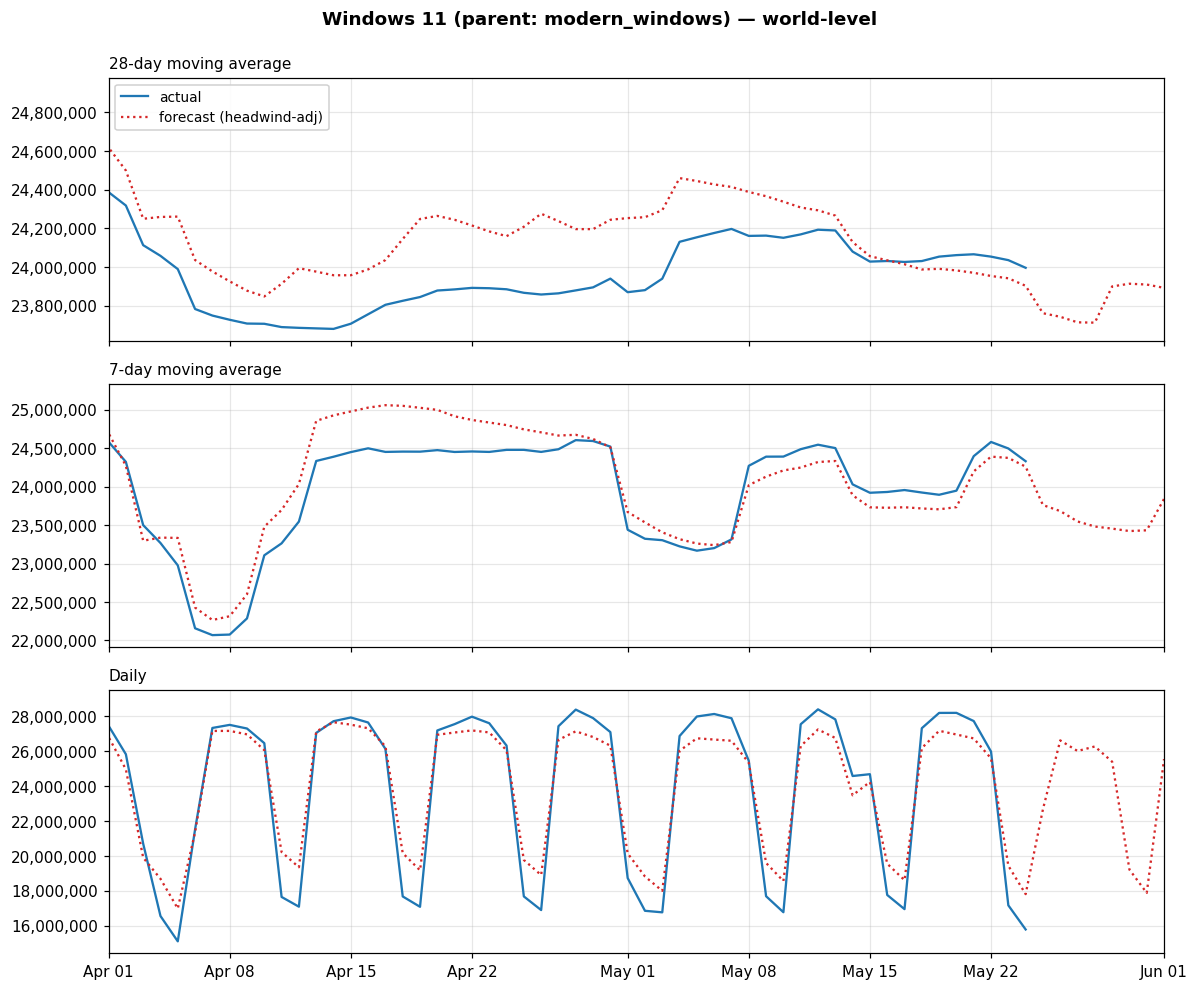

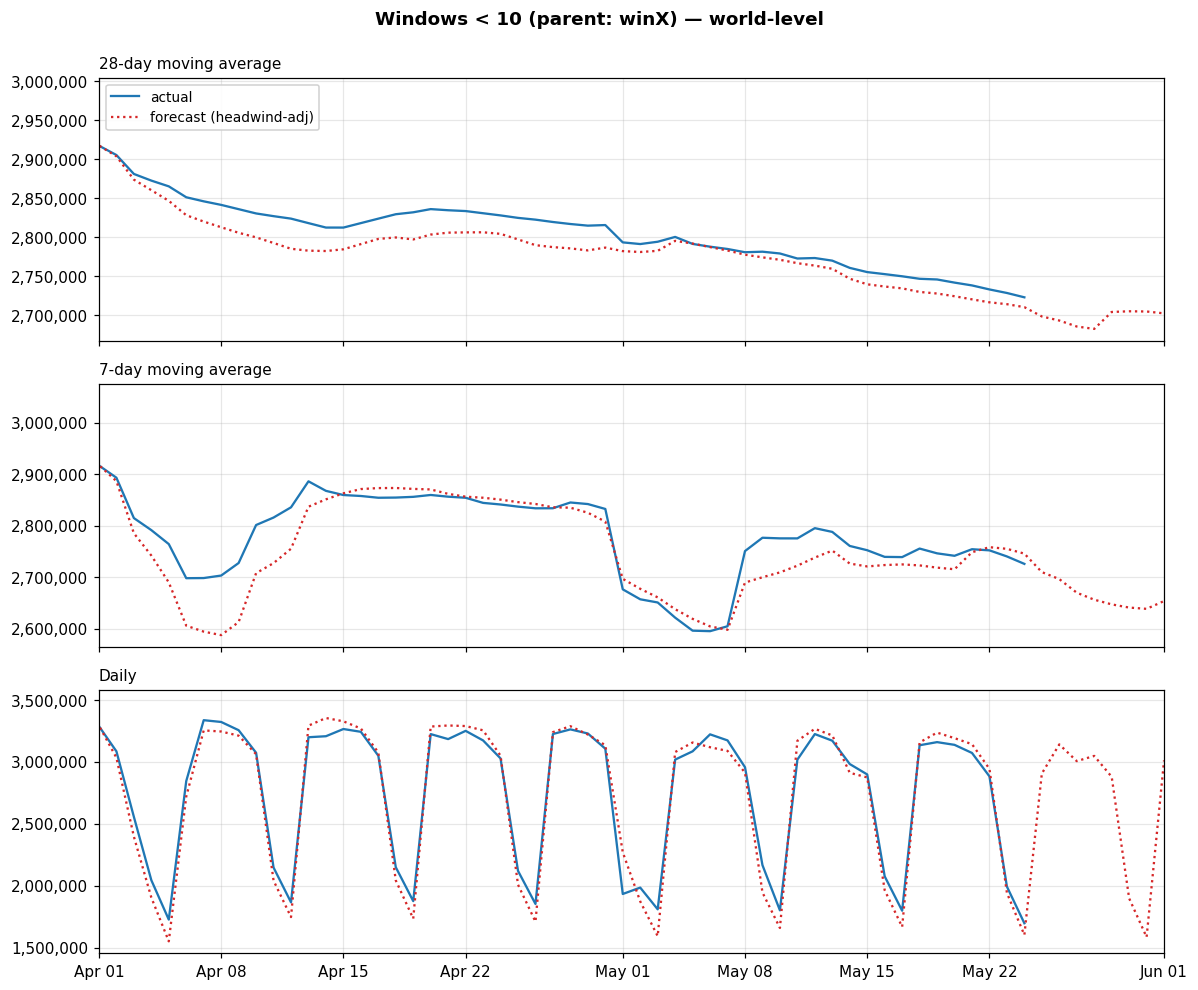

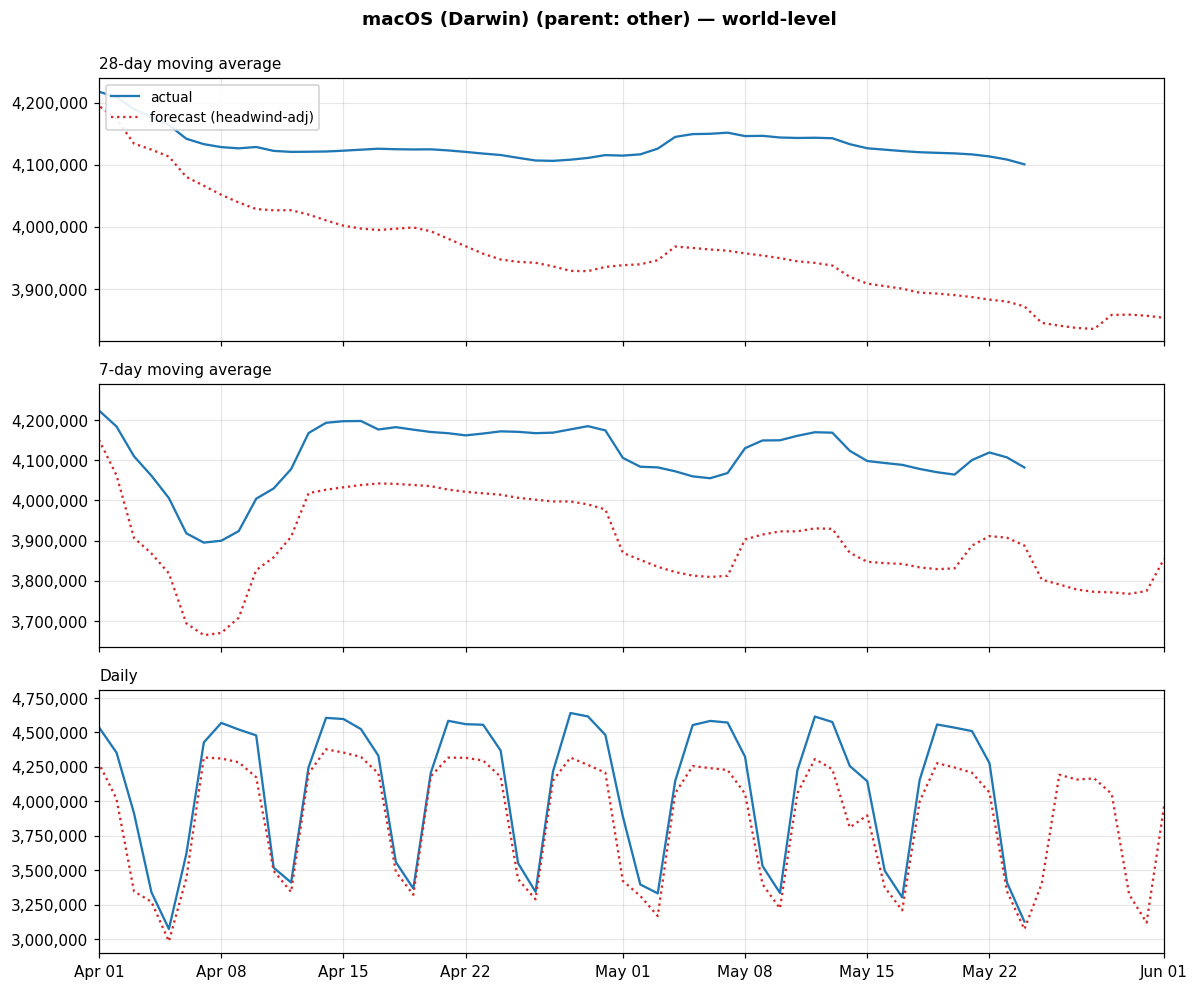

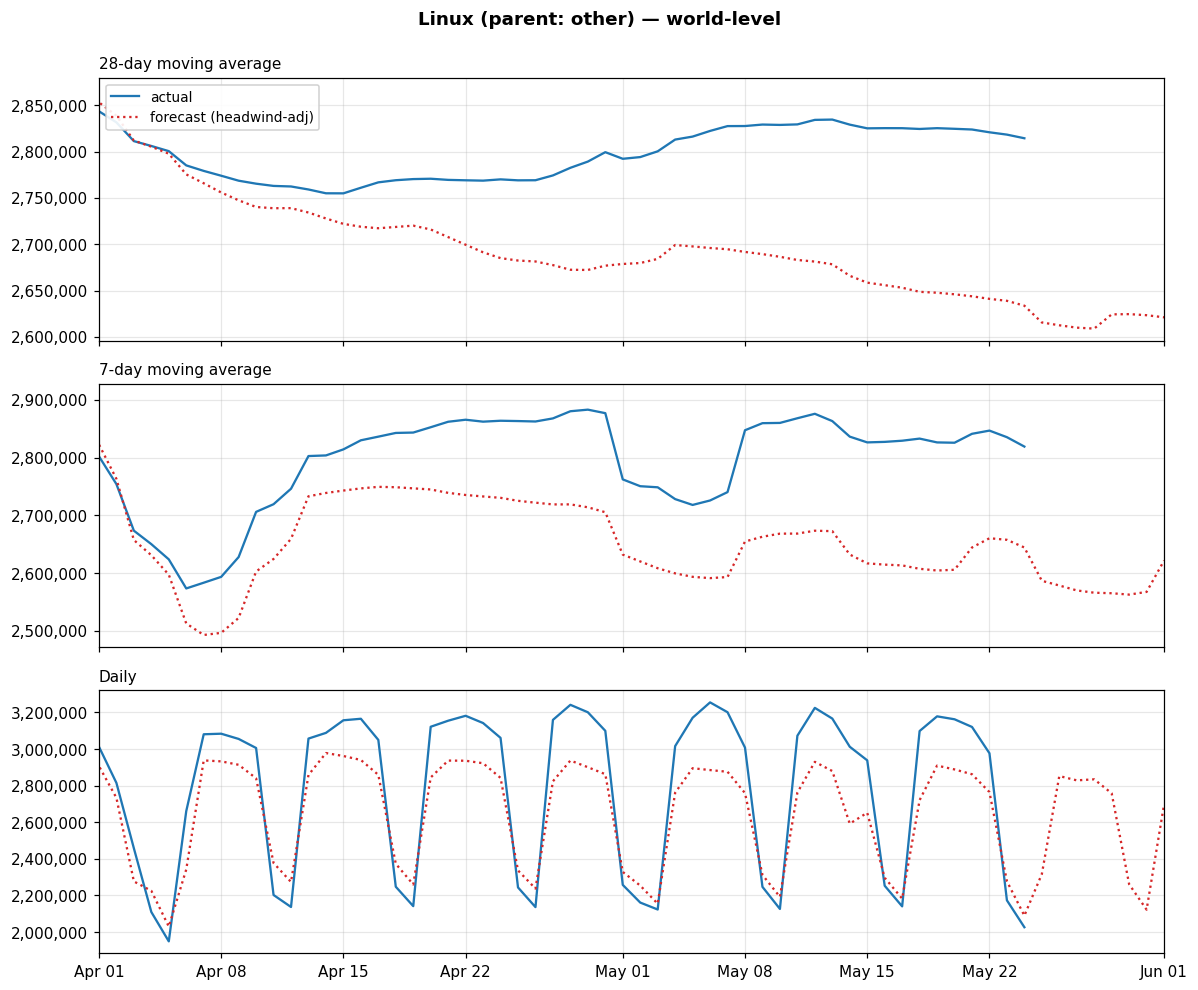

In [17]:
# [plot-os-classes]
show_entities(os_entities, title_suffix='world-level')


## 9. Share of gap vs share of total

Where is the rise actually coming from? For each entity *i* (country or OS class), compute over the **full post-FORECAST window**:

- `dau_share_i = mean(actual_i) / mean(actual_world)`
- `gap_share_i = mean(actual_i − forecast_i) / mean(actual_world − forecast_world)`  (signed)
- `gap_per_dau_i = gap_share_i / dau_share_i`

An entity above the diagonal in A — or with `gap_per_dau > 1` in B — contributes more to the gap than its size alone would predict. That's a real driver. An entity sitting on the diagonal is just absorbing world-level miss in proportion to its size.

Countries: 14 forecast-resolved + ROW as one bucket (15 entities). OS classes: 5 (Windows 10, Windows 11, Windows < 10, macOS, Linux).


In [18]:
# [build-gap-analysis]
def build_gap_df(named_entities):
    """For each (label, entity) pair, compute post-FORECAST window stats + daily gap series.

    The entity must carry actual_daily and forecast_daily. Returns a DataFrame
    indexed by label, plus a parallel dict of daily gap Series so the
    time-series plot (D) can read them without re-deriving.
    """
    rows = []
    daily_gaps = {}
    for label, e in named_entities:
        actual = e["actual_daily"].sort_index()
        forecast = e["forecast_daily"].sort_index()
        post_mask = actual.index >= FORECAST_START
        actual_post = actual.loc[post_mask]
        forecast_post = forecast.reindex(actual_post.index)
        gap_daily = actual_post - forecast_post
        daily_gaps[label] = gap_daily
        rows.append({
            "label":         label,
            "actual_mean":   float(actual_post.mean()),
            "forecast_mean": float(forecast_post.mean()),
            "gap_mean":      float(gap_daily.mean()),
        })
    df = pd.DataFrame(rows).set_index("label")
    df["dau_share"]   = df["actual_mean"] / df["actual_mean"].sum()
    df["gap_share"]   = df["gap_mean"]    / df["gap_mean"].sum()
    df["gap_per_dau"] = df["gap_share"]   / df["dau_share"]
    return df, daily_gaps


# --- Country-level entities: 14 forecast-resolved + ROW bucket ---
country_entities_for_gap = []
for region in REGIONS:
    for e in region_country_entities[region]:
        code = e["name"].split(" — ")[-1]
        country_entities_for_gap.append((code, e))
country_entities_for_gap.append(("ROW", row_total_entity))

# --- OS-level entities: strip the "(parent: ...)" suffix for cleaner labels ---
os_entities_for_gap = [(e["name"].split(" (")[0], e) for e in os_entities]

country_gap_df, country_daily_gaps = build_gap_df(country_entities_for_gap)
os_gap_df, os_daily_gaps           = build_gap_df(os_entities_for_gap)

print("=== Countries (sorted by gap_share desc) ===")
print((country_gap_df.sort_values("gap_share", ascending=False)
       [["actual_mean", "gap_mean", "dau_share", "gap_share", "gap_per_dau"]])
      .to_string(formatters={
          "actual_mean":   lambda v: f"{v:>14,.0f}",
          "gap_mean":      lambda v: f"{v:>+12,.0f}",
          "dau_share":     lambda v: f"{v:>+7.1%}",
          "gap_share":     lambda v: f"{v:>+7.1%}",
          "gap_per_dau":   lambda v: f"{v:>+7.2f}",
      }))

print("\n=== OS classes (sorted by gap_share desc) ===")
print((os_gap_df.sort_values("gap_share", ascending=False)
       [["actual_mean", "gap_mean", "dau_share", "gap_share", "gap_per_dau"]])
      .to_string(formatters={
          "actual_mean":   lambda v: f"{v:>14,.0f}",
          "gap_mean":      lambda v: f"{v:>+12,.0f}",
          "dau_share":     lambda v: f"{v:>+7.1%}",
          "gap_share":     lambda v: f"{v:>+7.1%}",
          "gap_per_dau":   lambda v: f"{v:>+7.2f}",
      }))


=== Countries (sorted by gap_share desc) ===
         actual_mean     gap_mean dau_share gap_share gap_per_dau
label                                                            
ROW       16,244,527     +257,868    +34.0%   +213.9%       +6.29
US         7,327,080      +66,358    +15.3%    +55.0%       +3.59
CA         1,138,782      +21,140     +2.4%    +17.5%       +7.36
CN         1,141,090      +11,001     +2.4%     +9.1%       +3.82
AR           402,680       +5,708     +0.8%     +4.7%       +5.62
ID         1,501,139       +5,363     +3.1%     +4.4%       +1.42
BR         1,927,381       +3,175     +4.0%     +2.6%       +0.65
RU         1,413,840       +2,983     +3.0%     +2.5%       +0.84
MX           743,533       -4,015     +1.6%     -3.3%       -2.14
PL         2,070,309       -9,594     +4.3%     -8.0%       -1.84
JP         1,082,776      -13,392     +2.3%    -11.1%       -4.90
IN         2,590,395      -14,979     +5.4%    -12.4%       -2.29
IT         1,368,271      -28,3

In [19]:
# [gap-plot-helpers]
def _bar_colors(values):
    """Green = over-contributor (>1), gray = under (0..1), red = counter (<0)."""
    return ["#2ca02c" if v > 1 else ("#d62728" if v < 0 else "#7f7f7f") for v in values]


def plot_gap_ab(df, dimension, *, title):
    """A (scatter, gap vs DAU share) and B (bar, gap_per_dau) side by side."""
    sorted_df = df.sort_values("gap_per_dau", ascending=False)
    colors = _bar_colors(sorted_df["gap_per_dau"])

    # ---- Interactive (plotly) ----
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            "A. Gap share vs DAU share (diagonal = proportional)",
            "B. Anomaly ratio (gap_share / dau_share)",
        ),
        horizontal_spacing=0.12,
    )
    fig.add_trace(go.Scatter(
        x=df["dau_share"], y=df["gap_share"],
        mode="markers+text", text=df.index, textposition="top center",
        marker=dict(size=10, color="#1f77b4"),
        name="entities", showlegend=False,
    ), row=1, col=1)
    lim_x = float(df["dau_share"].abs().max()) * 1.1
    lim_y = float(df["gap_share"].abs().max()) * 1.1
    lim = max(lim_x, lim_y)
    fig.add_trace(go.Scatter(
        x=[-lim, lim], y=[-lim, lim], mode="lines",
        line=dict(dash="dash", color="gray", width=1), showlegend=False,
    ), row=1, col=1)
    fig.add_trace(go.Bar(
        x=sorted_df.index, y=sorted_df["gap_per_dau"],
        text=[f"{v:+.2f}" for v in sorted_df["gap_per_dau"]],
        textposition="outside", marker_color=colors, showlegend=False,
    ), row=1, col=2)
    fig.add_hline(y=1, line=dict(dash="dash", color="gray", width=1), row=1, col=2)
    fig.add_hline(y=0, line=dict(color="black", width=0.7), row=1, col=2)
    fig.update_xaxes(title="DAU share", tickformat=".1%", row=1, col=1)
    fig.update_yaxes(title="gap share (signed)", tickformat=".1%", row=1, col=1)
    fig.update_yaxes(title="gap_per_dau (signed)", row=1, col=2)
    fig.update_xaxes(tickangle=-45, row=1, col=2)
    fig.update_layout(title=title, height=600, margin=dict(t=80, l=60, r=30, b=80))
    fig.show()

    # ---- Static (matplotlib) ----
    sfig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax = axes[0]
    ax.scatter(df["dau_share"], df["gap_share"], s=70, color="#1f77b4", zorder=3)
    for label, row in df.iterrows():
        ax.annotate(label, (row["dau_share"], row["gap_share"]),
                    textcoords="offset points", xytext=(6, 5), fontsize=9)
    ax.plot([-lim, lim], [-lim, lim], "--", color="gray", linewidth=1, zorder=1)
    ax.axhline(0, color="black", linewidth=0.5, zorder=1)
    ax.axvline(0, color="black", linewidth=0.5, zorder=1)
    ax.set_xlabel("DAU share")
    ax.set_ylabel("gap share (signed)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title("A. Gap share vs DAU share", loc="left", fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(range(len(sorted_df)), sorted_df["gap_per_dau"], color=colors)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df.index, rotation=45, ha="right", fontsize=9)
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("gap_per_dau (signed)")
    ax.set_title("B. Anomaly ratio (sorted)", loc="left", fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")
    sfig.suptitle(title, fontsize=12, fontweight="bold")
    sfig.tight_layout()
    plt.show()
    plt.close(sfig)


def plot_gap_c(df, dimension, *, title):
    """Pareto cumulative — concentration of gap drivers."""
    s = df.copy()
    s["abs_gap"] = s["gap_mean"].abs()
    s = s.sort_values("abs_gap", ascending=False)
    s["cum_dau"] = s["dau_share"].cumsum()
    s["cum_gap"] = s["gap_share"].cumsum()
    # Prepend origin so the line starts at (0, 0).
    x = pd.concat([pd.Series([0.0]), s["cum_dau"]]).values
    y = pd.concat([pd.Series([0.0]), s["cum_gap"]]).values
    labels = [""] + list(s.index)

    # ---- Interactive ----
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines+markers+text",
        text=labels, textposition="top right",
        line=dict(color="#1f77b4", width=2),
        marker=dict(size=8), name="cumulative",
    ))
    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1], mode="lines",
        line=dict(dash="dash", color="gray"), showlegend=False, name="proportional",
    ))
    fig.update_xaxes(title="Cumulative DAU share", tickformat=".0%", range=[-0.02, 1.02])
    fig.update_yaxes(title="Cumulative gap share (signed)", tickformat=".0%")
    fig.update_layout(title=title, height=500, margin=dict(t=80, l=60, r=30, b=60))
    fig.show()

    # ---- Static ----
    sfig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, "-o", color="#1f77b4", markersize=6, linewidth=1.5)
    for xi, yi, lab in zip(x[1:], y[1:], labels[1:]):
        ax.annotate(lab, (xi, yi), textcoords="offset points", xytext=(5, 5), fontsize=9)
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Cumulative DAU share (entities sorted by |gap| desc)")
    ax.set_ylabel("Cumulative gap share (signed)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    sfig.tight_layout()
    plt.show()
    plt.close(sfig)


def plot_gap_d(df, daily_gaps, dimension, *, title, top_n=5, smoothing=14):
    """Time-series of the top-N contributors: actual daily gap vs the gap each
    would have if it scaled exactly with DAU share. Distance between lines =
    excess contribution. Reference uses world_all to define the world gap."""
    world_gap = (
        world_all["actual_daily"].sort_index()
        - world_all["forecast_daily"].reindex(world_all["actual_daily"].index)
    )
    world_gap = world_gap.loc[world_gap.index >= FORECAST_START]
    world_gap_smooth = world_gap.rolling(smoothing).mean()

    s = df.copy()
    s["abs_gap"] = s["gap_mean"].abs()
    top = s.sort_values("abs_gap", ascending=False).head(top_n)

    palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    # ---- Interactive ----
    fig = make_subplots(
        rows=top_n, cols=1, shared_xaxes=True,
        subplot_titles=[f"{lab} — gap_per_dau = {top.loc[lab, 'gap_per_dau']:+.2f}" for lab in top.index],
        vertical_spacing=0.05,
    )
    for i, lab in enumerate(top.index, start=1):
        color = palette[(i - 1) % len(palette)]
        eg = daily_gaps[lab].rolling(smoothing).mean()
        proportional = world_gap_smooth * float(top.loc[lab, "dau_share"])
        fig.add_trace(go.Scatter(
            x=eg.index, y=eg.values, mode="lines",
            line=dict(color=color, width=2), name=f"{lab} actual gap",
            legendgroup=f"e{i}", showlegend=(i == 1),
        ), row=i, col=1)
        fig.add_trace(go.Scatter(
            x=proportional.index, y=proportional.values, mode="lines",
            line=dict(color=color, width=1, dash="dash"),
            name="if proportional to DAU share",
            legendgroup="ref", showlegend=(i == 1),
        ), row=i, col=1)
        fig.add_hline(y=0, line=dict(color="black", width=0.5), row=i, col=1)
    fig.update_layout(
        title=f"{title} — top {top_n} by |gap_mean|, {smoothing}d MA",
        height=200 * top_n + 80,
        margin=dict(t=80, l=60, r=30, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.show()

    # ---- Static ----
    sfig, axes = plt.subplots(top_n, 1, figsize=(12, 2.5 * top_n + 1), sharex=True)
    for i, lab in enumerate(top.index):
        ax = axes[i] if top_n > 1 else axes
        color = palette[i % len(palette)]
        eg = daily_gaps[lab].rolling(smoothing).mean()
        proportional = world_gap_smooth * float(top.loc[lab, "dau_share"])
        ax.plot(eg.index, eg.values, color=color, linewidth=1.8, label=f"{lab} actual gap")
        ax.plot(proportional.index, proportional.values, color=color,
                linewidth=1, linestyle="--", label="if proportional to DAU share")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(True, alpha=0.3)
        ax.set_title(f"{lab} — gap_per_dau = {top.loc[lab, 'gap_per_dau']:+.2f}",
                     loc="left", fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+,.0f}"))
        if i == 0:
            ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    sfig.suptitle(f"{title} — top {top_n} by |gap_mean|, {smoothing}d MA",
                  fontsize=12, fontweight="bold")
    sfig.tight_layout()
    plt.show()
    plt.close(sfig)


### 9a. Countries (14 forecast-resolved + ROW bucket)

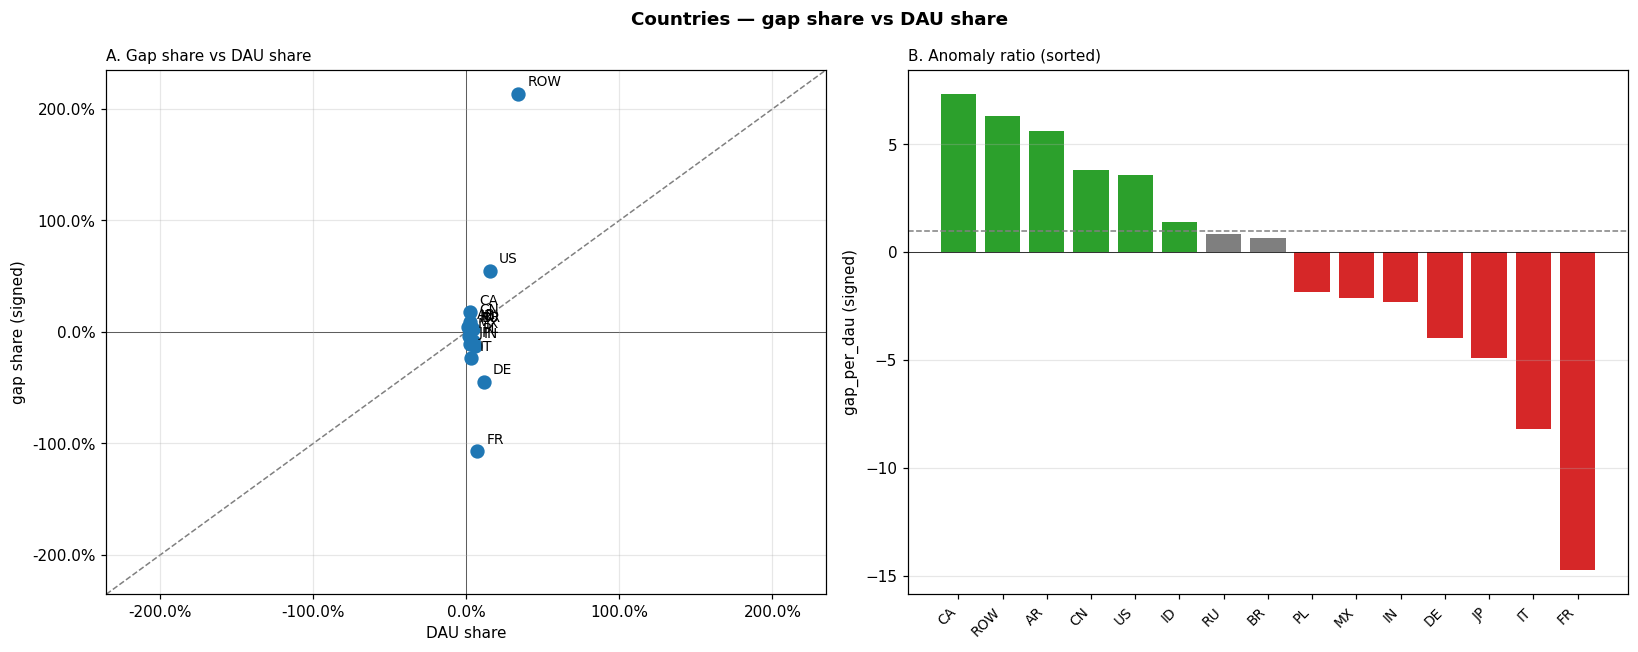

In [20]:
# [plot-gap-countries-ab]
plot_gap_ab(country_gap_df, 'countries', title='Countries — gap share vs DAU share')

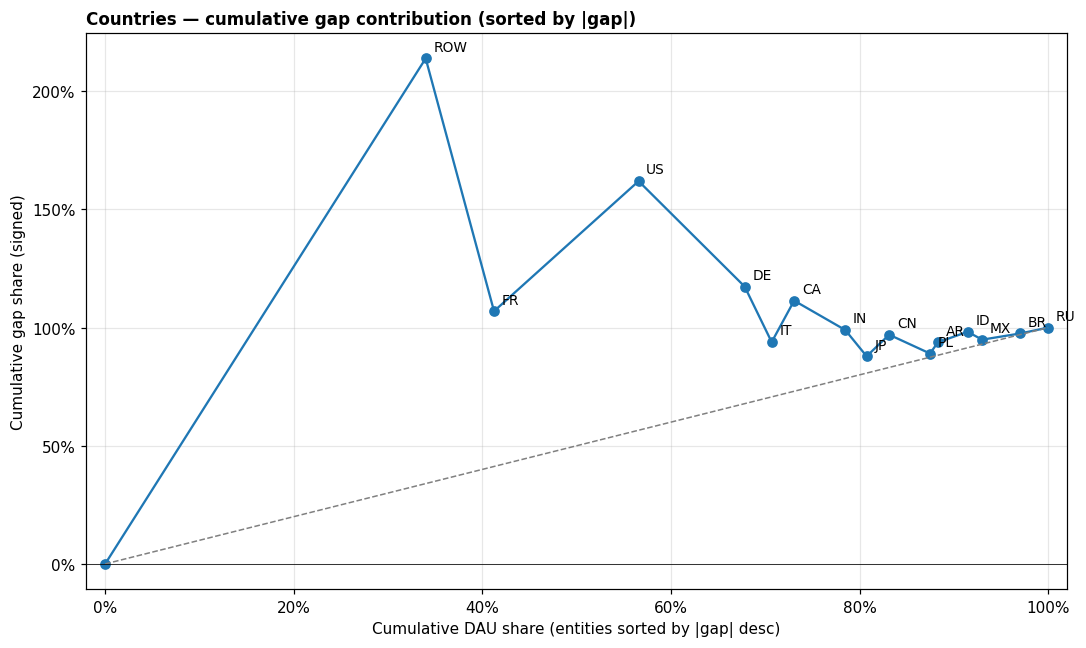

In [21]:
# [plot-gap-countries-c]
plot_gap_c(country_gap_df, 'countries', title='Countries — cumulative gap contribution (sorted by |gap|)')

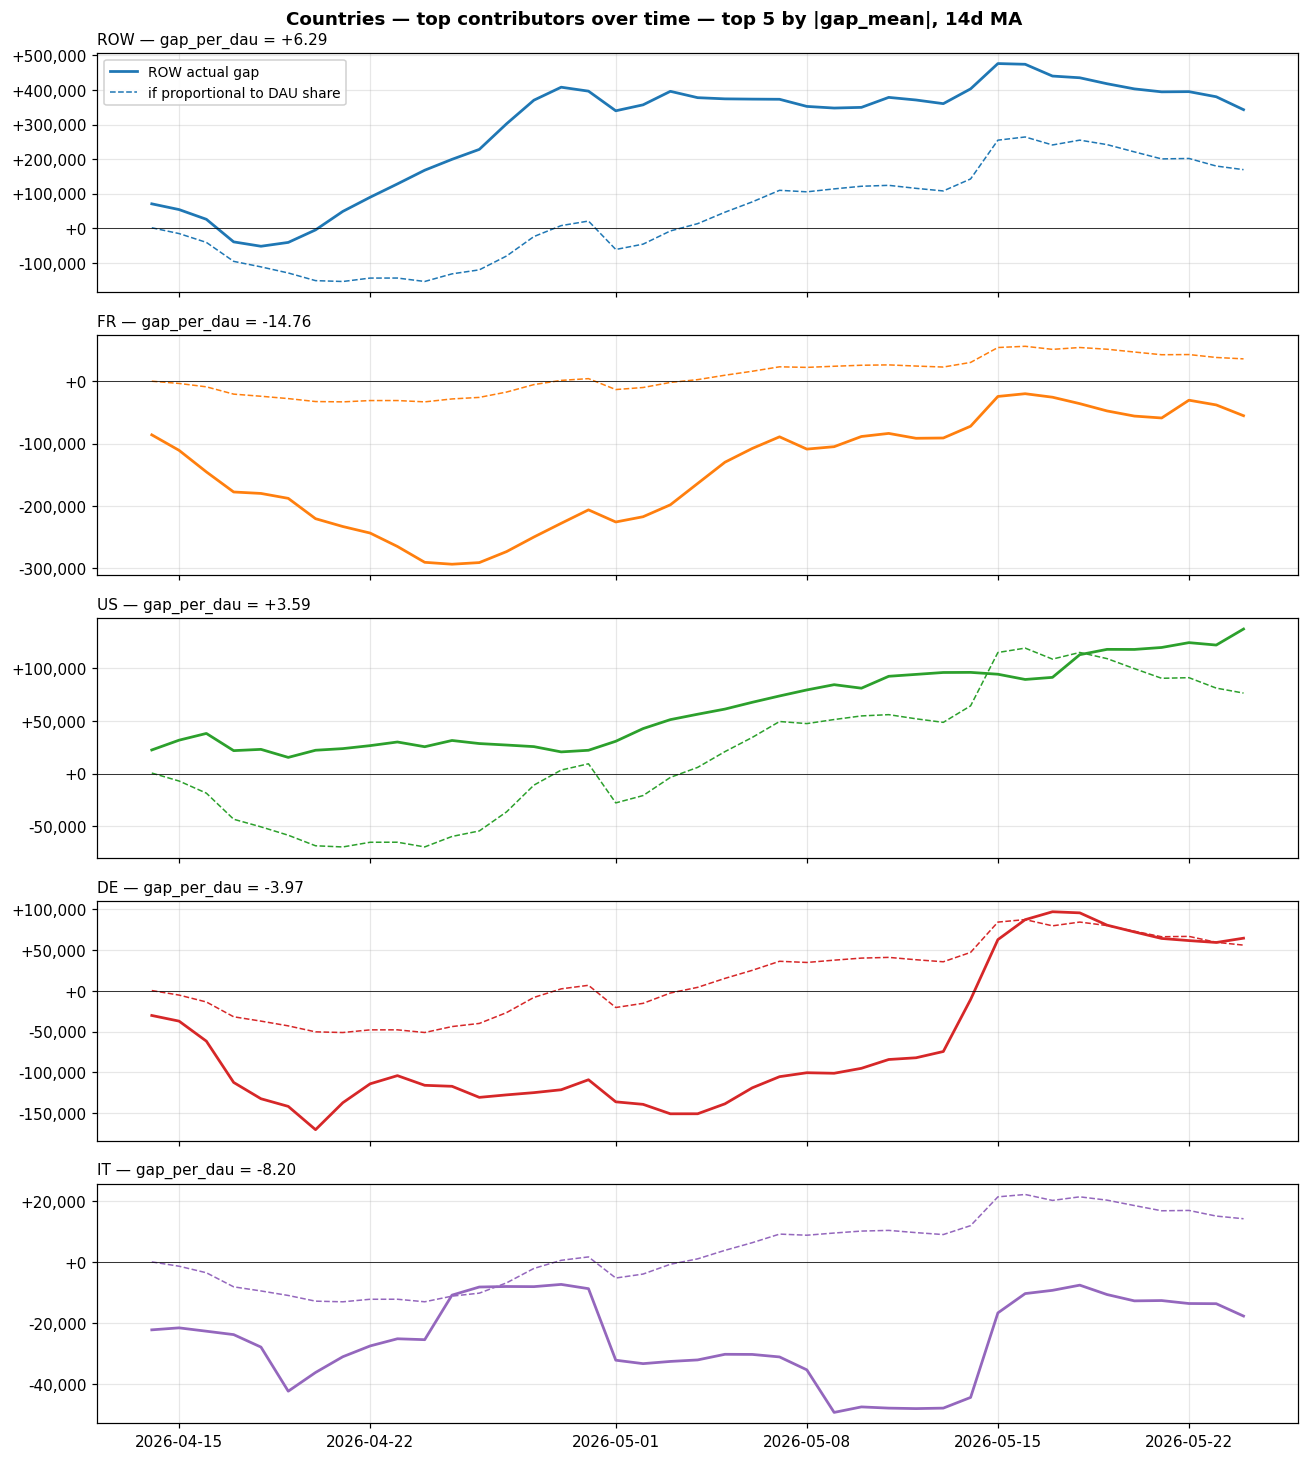

In [22]:
# [plot-gap-countries-d]
plot_gap_d(country_gap_df, country_daily_gaps, 'countries', title='Countries — top contributors over time', top_n=5, smoothing=14)

### 9b. OS classes (Win10 / Win11 / Win<10 / macOS / Linux)

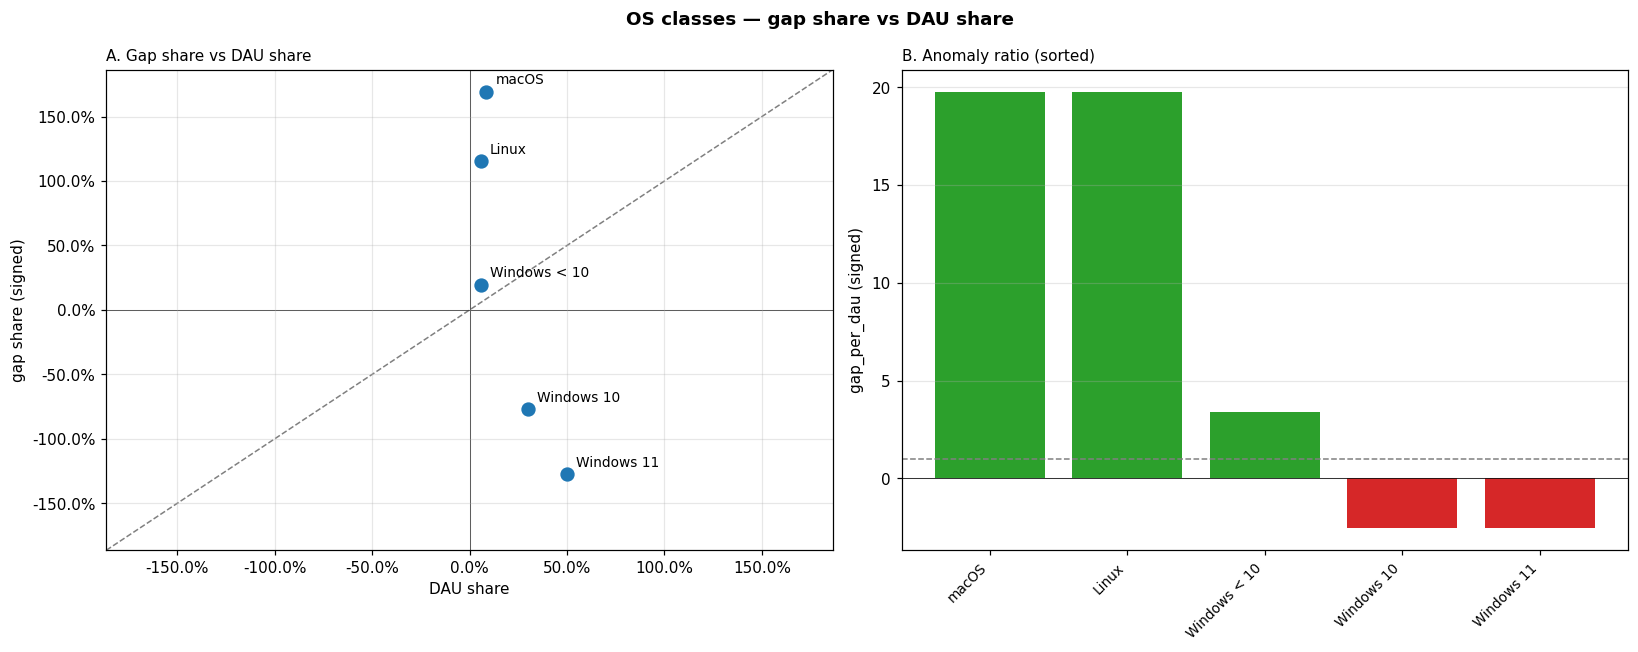

In [23]:
# [plot-gap-os-ab]
plot_gap_ab(os_gap_df, 'os', title='OS classes — gap share vs DAU share')

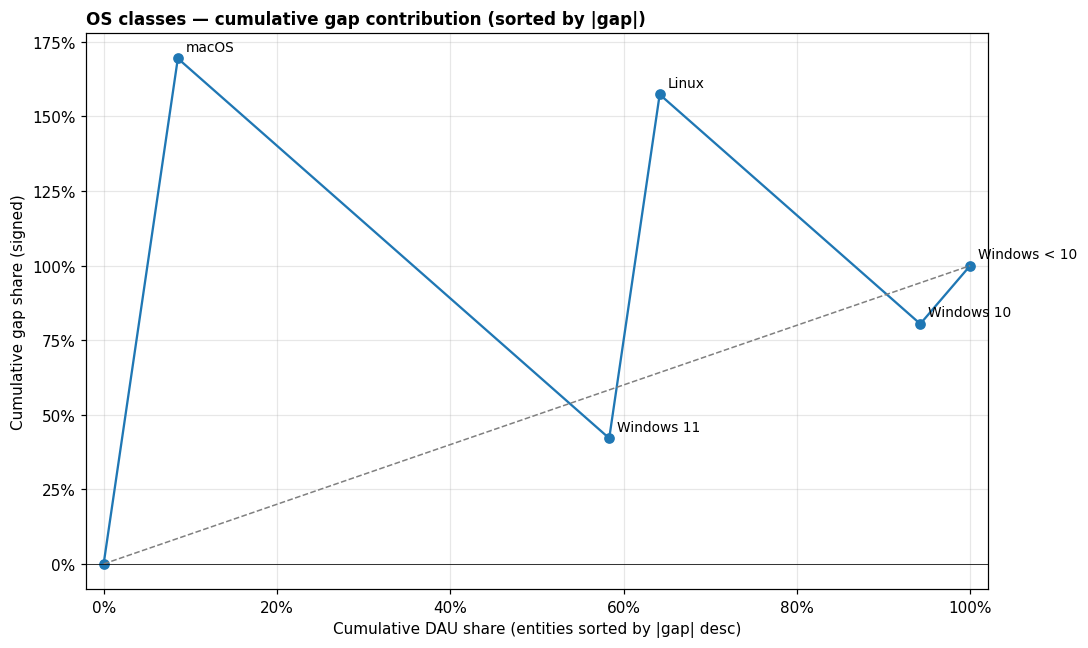

In [24]:
# [plot-gap-os-c]
plot_gap_c(os_gap_df, 'os', title='OS classes — cumulative gap contribution (sorted by |gap|)')

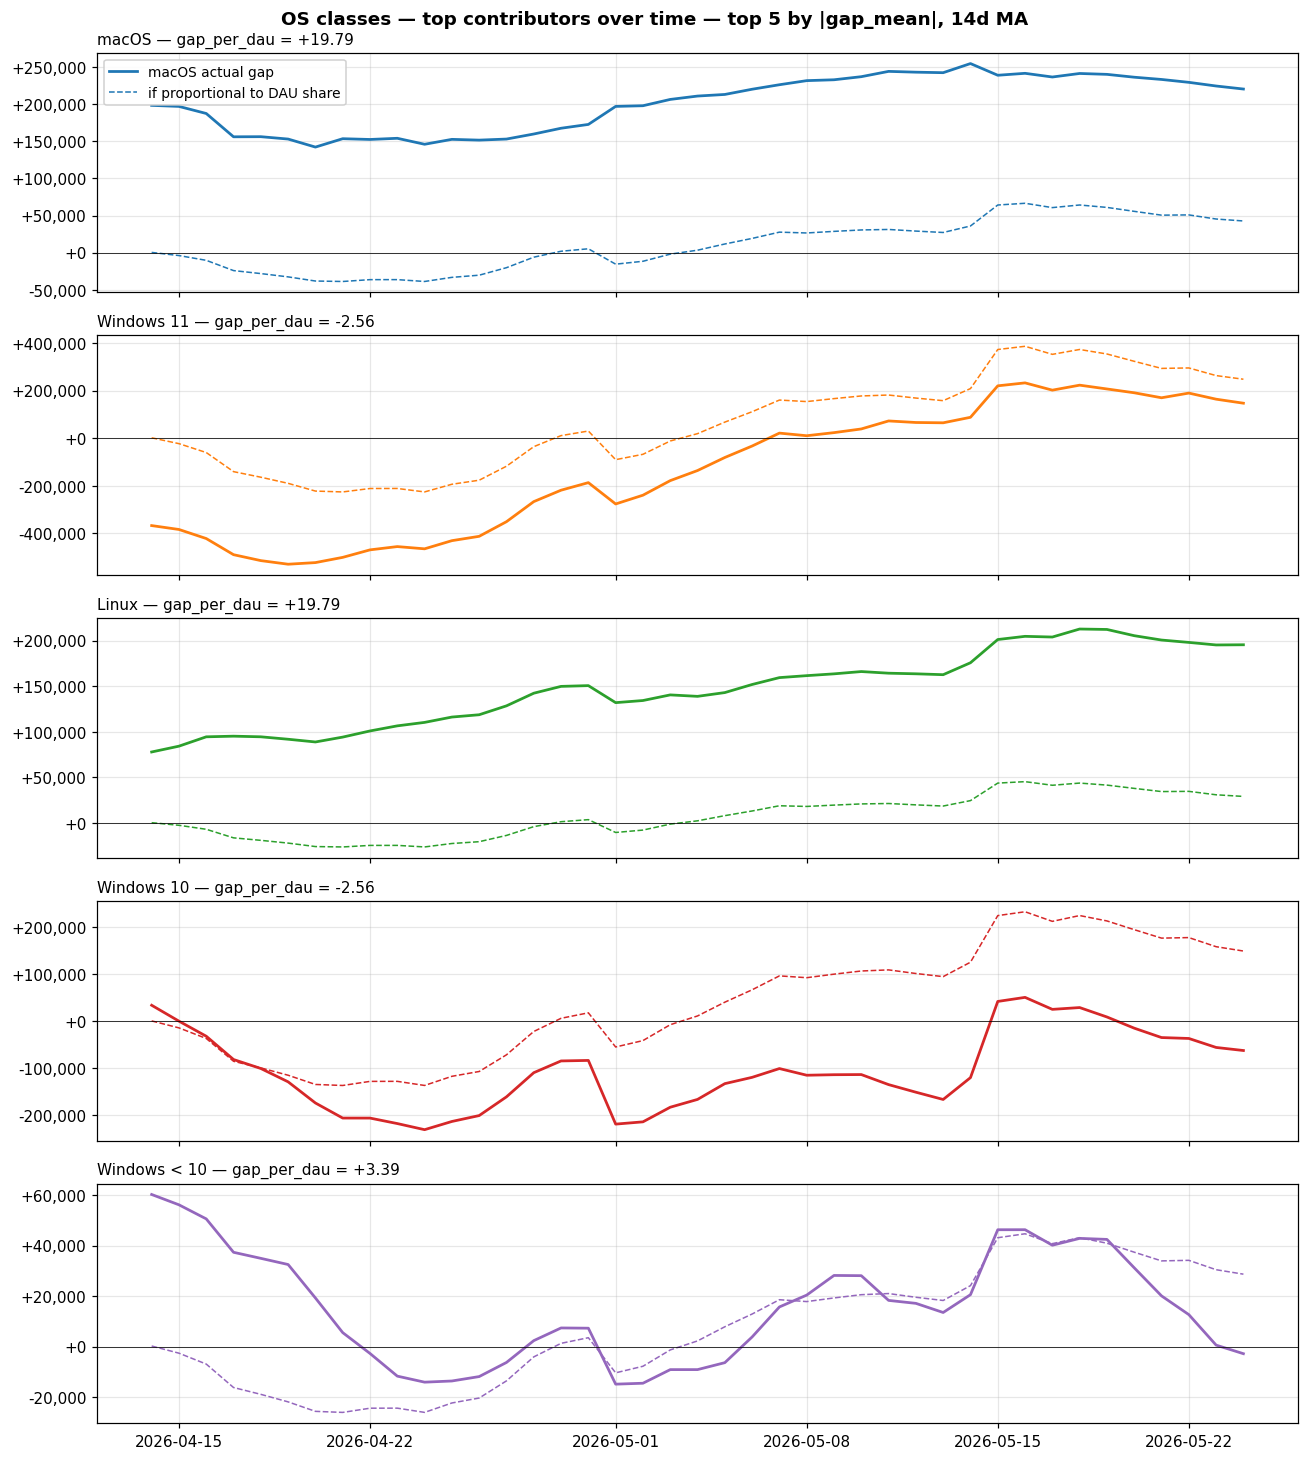

In [25]:
# [plot-gap-os-d]
plot_gap_d(os_gap_df, os_daily_gaps, 'os', title='OS classes — top contributors over time', top_n=5, smoothing=14)